<a href="https://colab.research.google.com/github/jangunru/weeding-invitation/blob/main/Data_Challengue_S%26P_Angel_Ruiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import os
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path



Helper functions


In [4]:
PARENT_DIR = Path("/content")
DATA_DIR = PARENT_DIR / "data_tlc"
TLC_DATA_DIR = DATA_DIR / "raw"
if not Path(DATA_DIR).exists():
  os.mkdir(DATA_DIR)
if not Path(TLC_DATA_DIR).exists():
  os.mkdir(TLC_DATA_DIR)

def get_tlc_data(year, month):
  url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month:02d}.parquet"
  response = requests.get(url)

  if response.status_code == 200:
      path =  TLC_DATA_DIR / f"rides_{year}_{month:02d}.parquet"
      open(path, "wb").write(response.content)
      return path
  else:
      raise Exception(f"{url} is not available")

def get_taxi_zones_data():
  url = f'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
  response = requests.get(url)

  if response.status_code == 200:
      path =  DATA_DIR / f"taxi_zone_lookup.csv"
      open(path, "wb").write(response.content)
      return path
  else:
      raise Exception(f"{url} is not available")



In [3]:
get_tlc_data(2025,1)
get_taxi_zones_data()

PosixPath('/content/data_tlc/taxi_zone_lookup.csv')

In [4]:
rides = pd.read_parquet('/content/data_tlc/raw/rides_2025_01.parquet')
rides.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0
5,2,2025-01-01 00:48:24,2025-01-01 01:08:26,2.0,2.63,1.0,N,239,68,2,19.1,1.0,0.5,0.00,0.0,1.0,24.10,2.5,0.0,0.0
6,1,2025-01-01 00:14:47,2025-01-01 00:16:15,0.0,0.40,1.0,N,170,170,1,4.4,3.5,0.5,2.35,0.0,1.0,11.75,2.5,0.0,0.0
7,1,2025-01-01 00:39:27,2025-01-01 00:51:51,0.0,1.60,1.0,N,234,148,1,12.1,3.5,0.5,2.00,0.0,1.0,19.10,2.5,0.0,0.0
8,1,2025-01-01 00:53:43,2025-01-01 01:13:23,0.0,2.80,1.0,N,148,170,1,19.1,3.5,0.5,3.00,0.0,1.0,27.10,2.5,0.0,0.0
9,2,2025-01-01 00:00:02,2025-01-01 00:09:36,1.0,1.71,1.0,N,237,262,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.0,0.0


In [5]:

zones =  pd.read_csv('/content/data_tlc/taxi_zone_lookup.csv')
zones.head(10)

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
5,6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone
6,7,Queens,Astoria,Boro Zone
7,8,Queens,Astoria Park,Boro Zone
8,9,Queens,Auburndale,Boro Zone
9,10,Queens,Baisley Park,Boro Zone


In [6]:
rides.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01
std,4.263282e-01,NaN,NaN,7.507503e-01,5.646016e+02,1.163277e+01,6.452948e+01,6.940169e+01,7.013334e-01,4.634729e+02,1.861509e+00,1.374623e-01,3.779681e+00,2.002582e+00,2.781938e-01,4.636585e+02,9.039932e-01,4.725090e-01,3.619307e-01


In [7]:
rides.dtypes

,0
VendorID,int32
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,object
PULocationID,int32
DOLocationID,int32
payment_type,int64


In [8]:
rides.drop(['VendorID','passenger_count', 'RatecodeID','store_and_fwd_flag', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'cbd_congestion_fee', 'Airport_fee'], axis=1, inplace=True)
print('Total data: ', len(rides))
rides.head()

Total data:  3475226


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,payment_type,tip_amount,total_amount
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.60,229,237,1,3.00,18.00
1,2025-01-01 00:32:40,2025-01-01 00:35:13,0.50,236,237,1,2.02,12.12
2,2025-01-01 00:44:04,2025-01-01 00:46:01,0.60,141,141,1,2.00,12.10
3,2025-01-01 00:14:27,2025-01-01 00:20:01,0.52,244,244,2,0.00,9.70
4,2025-01-01 00:21:34,2025-01-01 00:25:06,0.66,244,116,2,0.00,8.30


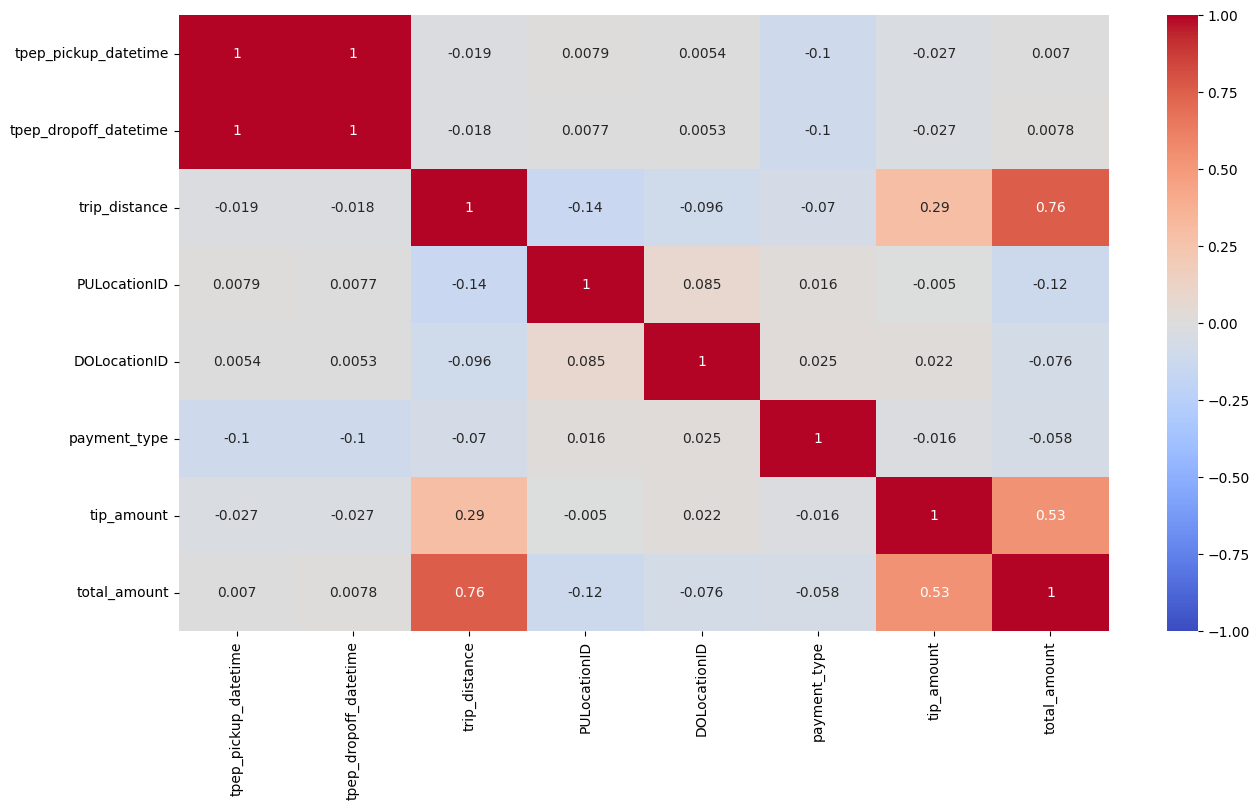

In [9]:
plt.figure(figsize=(15,8))
sns.heatmap(rides.corr('spearman'), vmin=-1, vmax=1, annot=True, cmap="coolwarm")
plt.show()

In [10]:
print(f"Rides shape before removing duplicates: {rides.shape}")
rides.drop_duplicates(inplace=True)
print(f"Rides shape after removing duplicates: {rides.shape}")

Rides shape before removing duplicates: (3475226, 8)
Rides shape after removing duplicates: (3475226, 8)


In [11]:
rides_neg = rides[rides['total_amount']<=0]
rides_neg.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,payment_type,tip_amount,total_amount
17,2025-01-01 00:01:41,2025-01-01 00:07:14,0.71,79,107,2,3.66,-8.54
22,2025-01-01 00:55:54,2025-01-01 01:00:38,0.69,137,233,4,0.00,-11.50
104,2025-01-01 00:56:12,2025-01-01 01:15:00,0.97,161,170,4,0.00,-21.30
149,2025-01-01 00:55:53,2025-01-01 01:06:49,1.42,79,45,2,0.00,-17.10
202,2025-01-01 00:29:35,2025-01-01 00:36:02,0.60,79,148,4,0.00,-12.20


In [12]:
rides.drop(rides_neg.index, inplace=True)

In [13]:
rides.isna().mean()


,0
tpep_pickup_datetime,0.0
tpep_dropoff_datetime,0.0
trip_distance,0.0
PULocationID,0.0
DOLocationID,0.0
payment_type,0.0
tip_amount,0.0
total_amount,0.0


Preprocess data

In [14]:
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'
rides["time_day"] = rides["tpep_pickup_datetime"].dt.hour.apply(get_time_of_day)
rides["day_week"] = rides["tpep_pickup_datetime"].dt.day_name()
rides["day_category"] = np.where(rides["tpep_pickup_datetime"].dt.weekday < 5, "Weekday", "Weekend")
rides.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,payment_type,tip_amount,total_amount,time_day,day_week,day_category
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.60,229,237,1,3.00,18.00,Night,Wednesday,Weekday
1,2025-01-01 00:32:40,2025-01-01 00:35:13,0.50,236,237,1,2.02,12.12,Night,Wednesday,Weekday
2,2025-01-01 00:44:04,2025-01-01 00:46:01,0.60,141,141,1,2.00,12.10,Night,Wednesday,Weekday
3,2025-01-01 00:14:27,2025-01-01 00:20:01,0.52,244,244,2,0.00,9.70,Night,Wednesday,Weekday
4,2025-01-01 00:21:34,2025-01-01 00:25:06,0.66,244,116,2,0.00,8.30,Night,Wednesday,Weekday


In [15]:
rides['time_trip'] = (rides['tpep_dropoff_datetime'] - rides['tpep_pickup_datetime']).dt.total_seconds() / 60
rides['time_bucket'] = pd.cut(
    rides['time_trip'], bins = [0,10,20,30,60,1000],
    labels = ["<10min", "10-20min", "20-30min", "30-60min", ">60min"]
)
rides['distance_bucket'] = pd.cut(
    rides['trip_distance'], bins = [0,2,5,10,20,1000],
    labels = ["<2mi", "2-5mi", "5-10mi", "10-20mi", ">20mi"]
)
rides["amount_bucket"] =  pd.cut(
    rides['total_amount'], bins = [-100, 0,10,20,40,80,1000],
    labels = ["Neg", "<10", "10-20", "20-40", "40-80", ">80"]
)
rides.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,payment_type,tip_amount,total_amount,time_day,day_week,day_category,time_trip,time_bucket,distance_bucket,amount_bucket
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.60,229,237,1,3.00,18.00,Night,Wednesday,Weekday,8.350000,<10min,<2mi,10-20
1,2025-01-01 00:32:40,2025-01-01 00:35:13,0.50,236,237,1,2.02,12.12,Night,Wednesday,Weekday,2.550000,<10min,<2mi,10-20
2,2025-01-01 00:44:04,2025-01-01 00:46:01,0.60,141,141,1,2.00,12.10,Night,Wednesday,Weekday,1.950000,<10min,<2mi,10-20
3,2025-01-01 00:14:27,2025-01-01 00:20:01,0.52,244,244,2,0.00,9.70,Night,Wednesday,Weekday,5.566667,<10min,<2mi,<10
4,2025-01-01 00:21:34,2025-01-01 00:25:06,0.66,244,116,2,0.00,8.30,Night,Wednesday,Weekday,3.533333,<10min,<2mi,<10


In [16]:
payment_category = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided'
}
rides['payment_cat'] = rides['payment_type'].map(payment_category).astype("category")
rides = rides.merge(zones[["LocationID", "Zone", "Borough"]],
      left_on="PULocationID", right_on="LocationID",
      how="left").rename(columns={"Zone": "pu_loc_zone", "Borough":"pu_loc_borough"})
rides = rides.merge(zones[["LocationID", "Zone", "Borough"]],
      left_on="DOLocationID", right_on="LocationID",
      how="left").rename(columns={"Zone": "do_loc_zone", "Borough":"do_loc_borough"})
rides.head()


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,payment_type,tip_amount,total_amount,time_day,day_week,...,time_bucket,distance_bucket,amount_bucket,payment_cat,LocationID_x,pu_loc_zone,pu_loc_borough,LocationID_y,do_loc_zone,do_loc_borough
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.60,229,237,1,3.00,18.00,Night,Wednesday,...,<10min,<2mi,10-20,Credit Card,229,Sutton Place/Turtle Bay North,Manhattan,237,Upper East Side South,Manhattan
1,2025-01-01 00:32:40,2025-01-01 00:35:13,0.50,236,237,1,2.02,12.12,Night,Wednesday,...,<10min,<2mi,10-20,Credit Card,236,Upper East Side North,Manhattan,237,Upper East Side South,Manhattan
2,2025-01-01 00:44:04,2025-01-01 00:46:01,0.60,141,141,1,2.00,12.10,Night,Wednesday,...,<10min,<2mi,10-20,Credit Card,141,Lenox Hill West,Manhattan,141,Lenox Hill West,Manhattan
3,2025-01-01 00:14:27,2025-01-01 00:20:01,0.52,244,244,2,0.00,9.70,Night,Wednesday,...,<10min,<2mi,<10,Cash,244,Washington Heights South,Manhattan,244,Washington Heights South,Manhattan
4,2025-01-01 00:21:34,2025-01-01 00:25:06,0.66,244,116,2,0.00,8.30,Night,Wednesday,...,<10min,<2mi,<10,Cash,244,Washington Heights South,Manhattan,116,Hamilton Heights,Manhattan


Analysis

In [17]:
rides.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance',
       'PULocationID', 'DOLocationID', 'payment_type', 'tip_amount',
       'total_amount', 'time_day', 'day_week', 'day_category', 'time_trip',
       'time_bucket', 'distance_bucket', 'amount_bucket', 'payment_cat',
       'LocationID_x', 'pu_loc_zone', 'pu_loc_borough', 'LocationID_y',
       'do_loc_zone', 'do_loc_borough'],
      dtype='object')

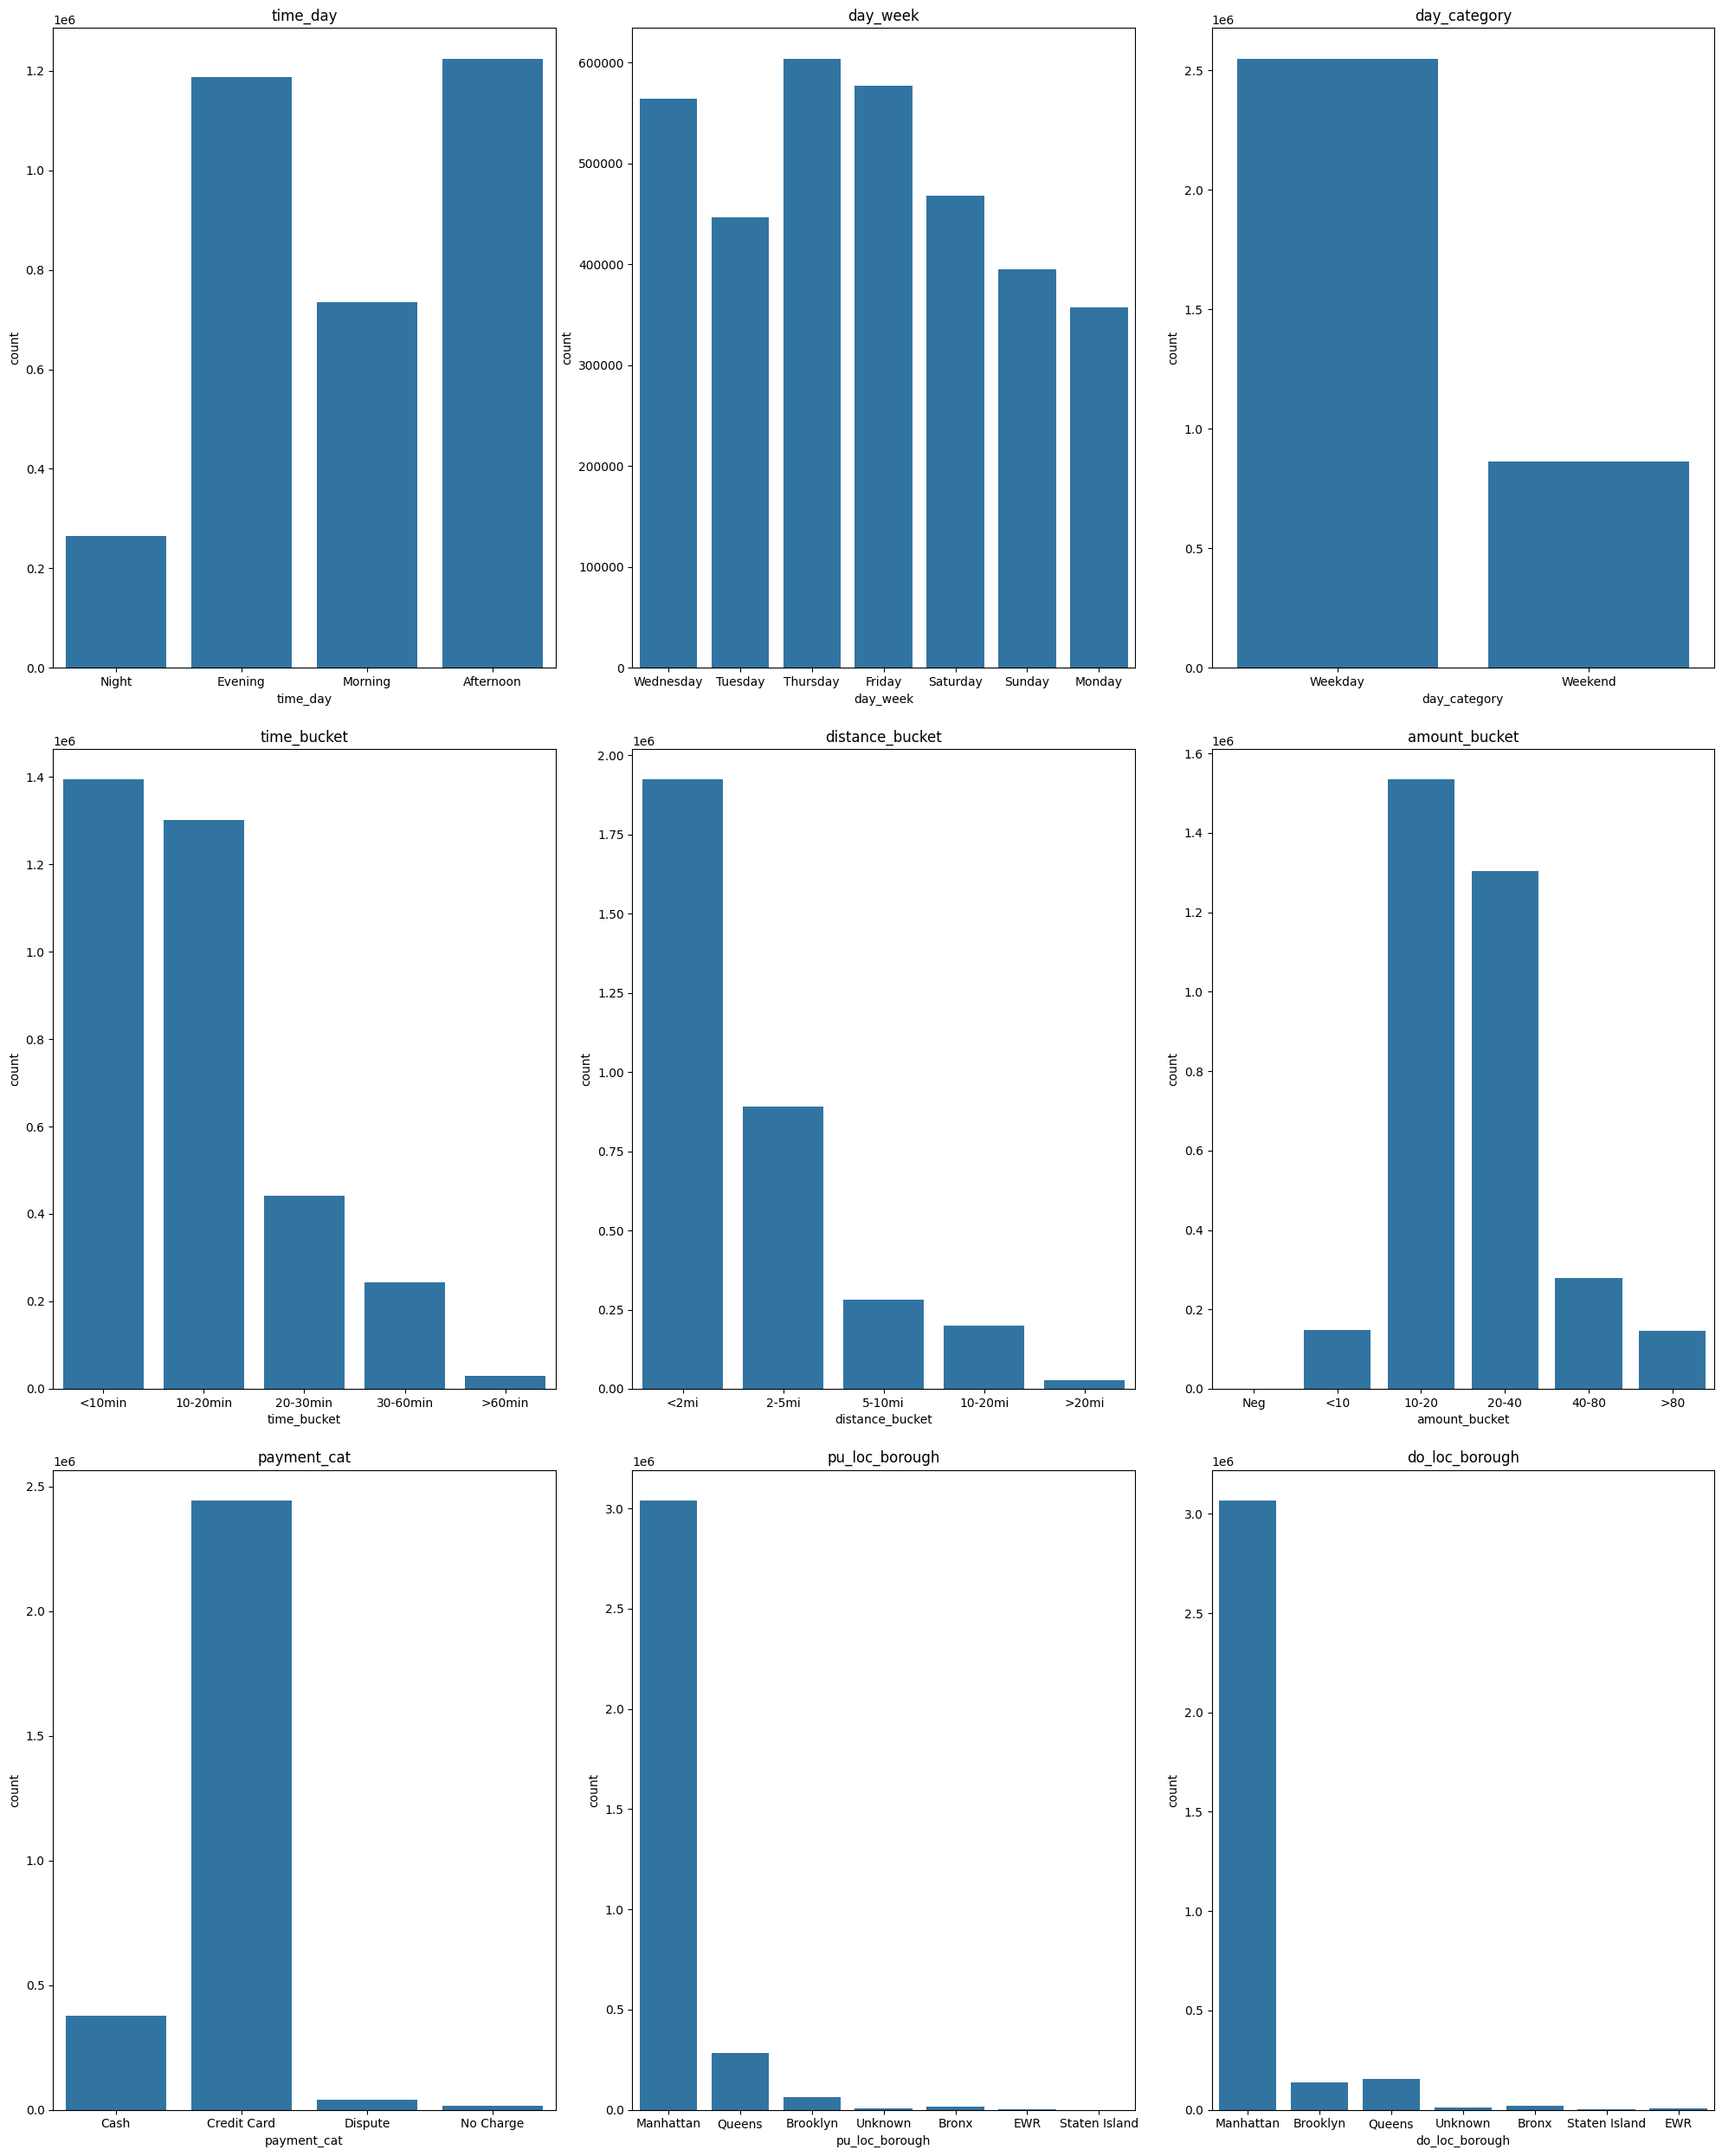

In [18]:



columns = ['time_day','day_week', 'day_category', 'time_bucket', 'distance_bucket', 'amount_bucket', 'payment_cat','pu_loc_borough', 'do_loc_borough']

fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(20,25))
axs = axs.flatten()

for i, col in enumerate(columns):
  bars = sns.countplot(data=rides, x=col, ax=axs[i])
  axs[i].set_title(col)

plt.tight_layout(w_pad=0.5, h_pad=2)
plt.show()


In [19]:
rides.drop([ 'LocationID_y', 'LocationID_x', 'DOLocationID', 'PULocationID', 'payment_type'], axis=1, inplace=True)
rides.select_dtypes(include=[np.number])

,trip_distance,tip_amount,total_amount,time_trip
0,1.60,3.00,18.00,8.350000
1,0.50,2.02,12.12,2.550000
2,0.60,2.00,12.10,1.950000
3,0.52,0.00,9.70,5.566667
4,0.66,0.00,8.30,3.533333
...,...,...,...,...
3411625,3.35,0.00,20.60,14.683333
3411626,8.73,0.00,32.89,26.966667
3411627,2.64,0.00,19.66,16.033333
3411628,3.16,0.00,22.30,20.300000


In [20]:
numeric_cols = rides.select_dtypes(include=[np.number]).columns[:4]
numeric_cols

Index(['trip_distance', 'tip_amount', 'total_amount', 'time_trip'], dtype='object')

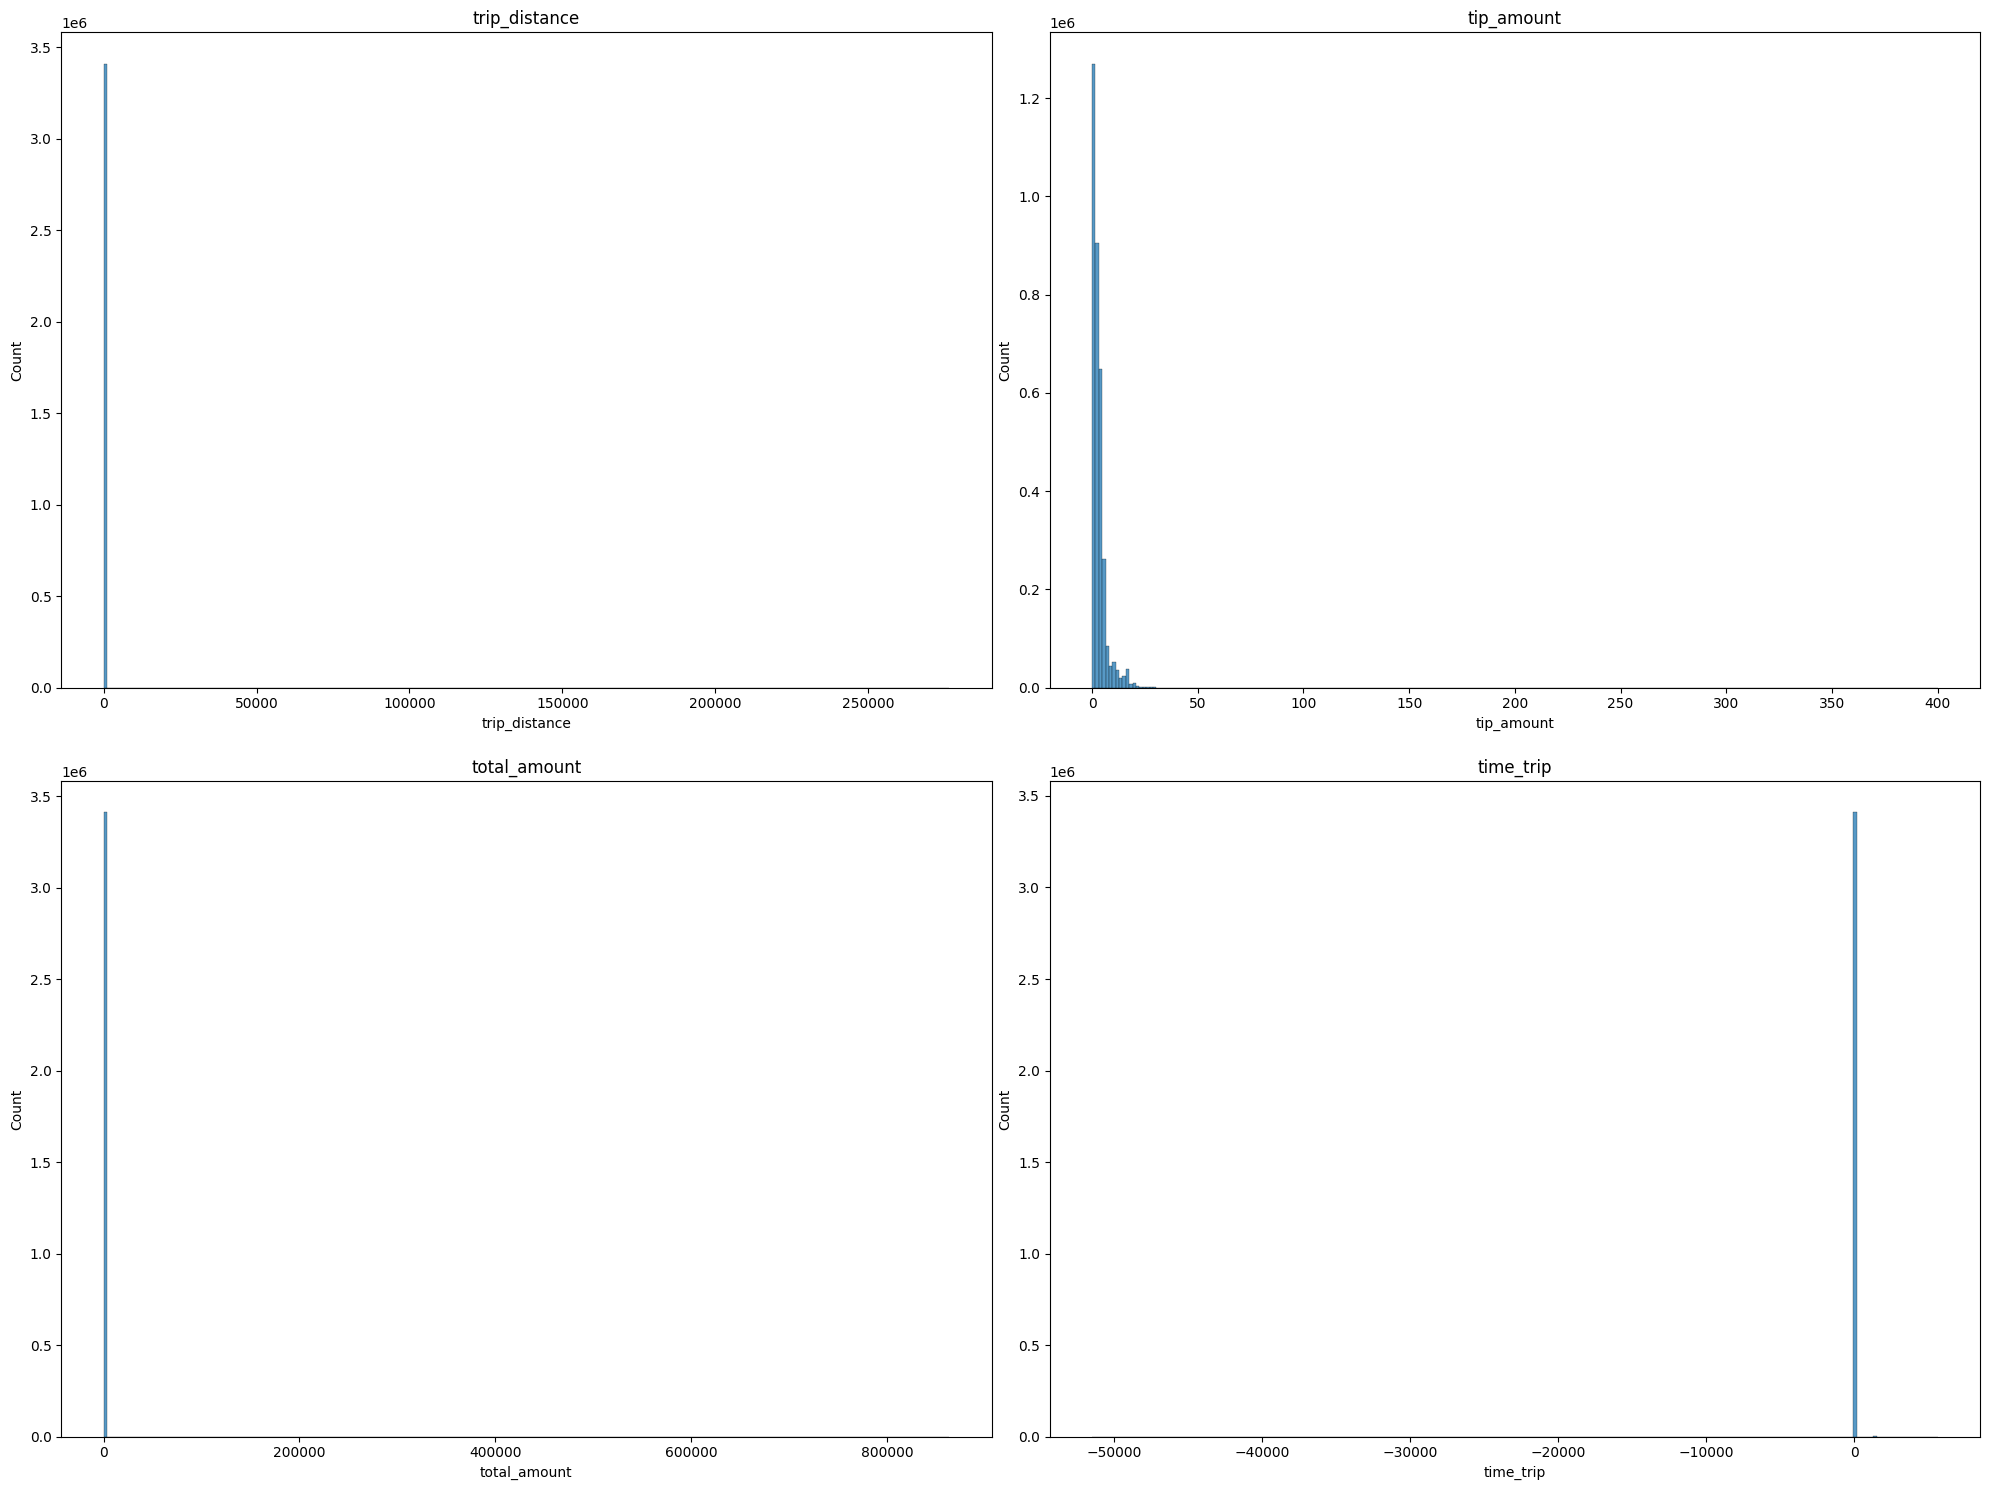

In [21]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20,15))
index = 0
axs = axs.flatten()
for i, col in enumerate(numeric_cols):
    axs[i].set_title(col)
    sns.histplot(
        data=rides,
        x=col,
        bins=250,
        ax=axs[i]
    )
plt.tight_layout(w_pad=0.5, h_pad=2)
plt.show()

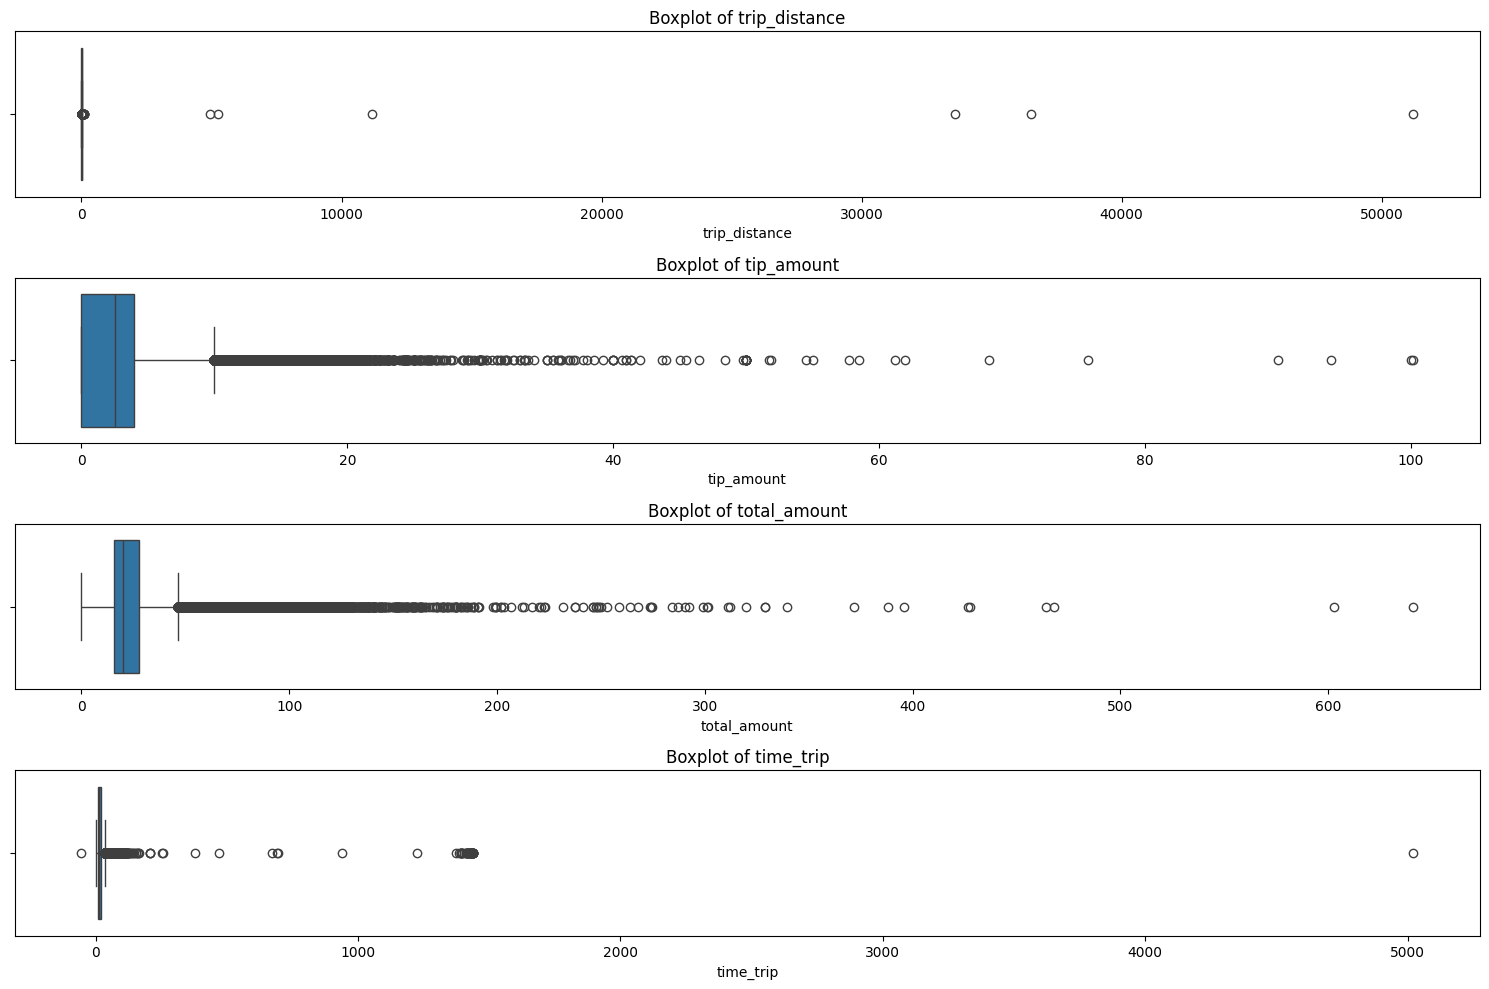

In [22]:

numeric_cols = rides.select_dtypes(include=[np.number]).columns.tolist()

rides_sample = rides[numeric_cols].sample(100_000, random_state=42)


fig, axs = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=rides_sample, x=col, ax=axs[i])
    axs[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [23]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

bounds = {}

for col in numeric_cols:
    lower, upper = iqr_bounds(rides[col])
    bounds[col] = (lower, upper)

bounds

{'trip_distance': (np.float64(-2.1750000000000007),
  np.float64(6.265000000000001)),
 'tip_amount': (np.float64(-5.985), np.float64(9.975000000000001)),
 'total_amount': (np.float64(-3.1999999999999993), np.float64(46.72)),
 'time_trip': (np.float64(-9.233333333333338), np.float64(34.900000000000006))}

In [24]:
clean_rides = rides.copy()

for col in numeric_cols:
    lower, upper = bounds[col]
    clean_rides = clean_rides[(clean_rides[col] >= lower) & (clean_rides[col] <= upper)]

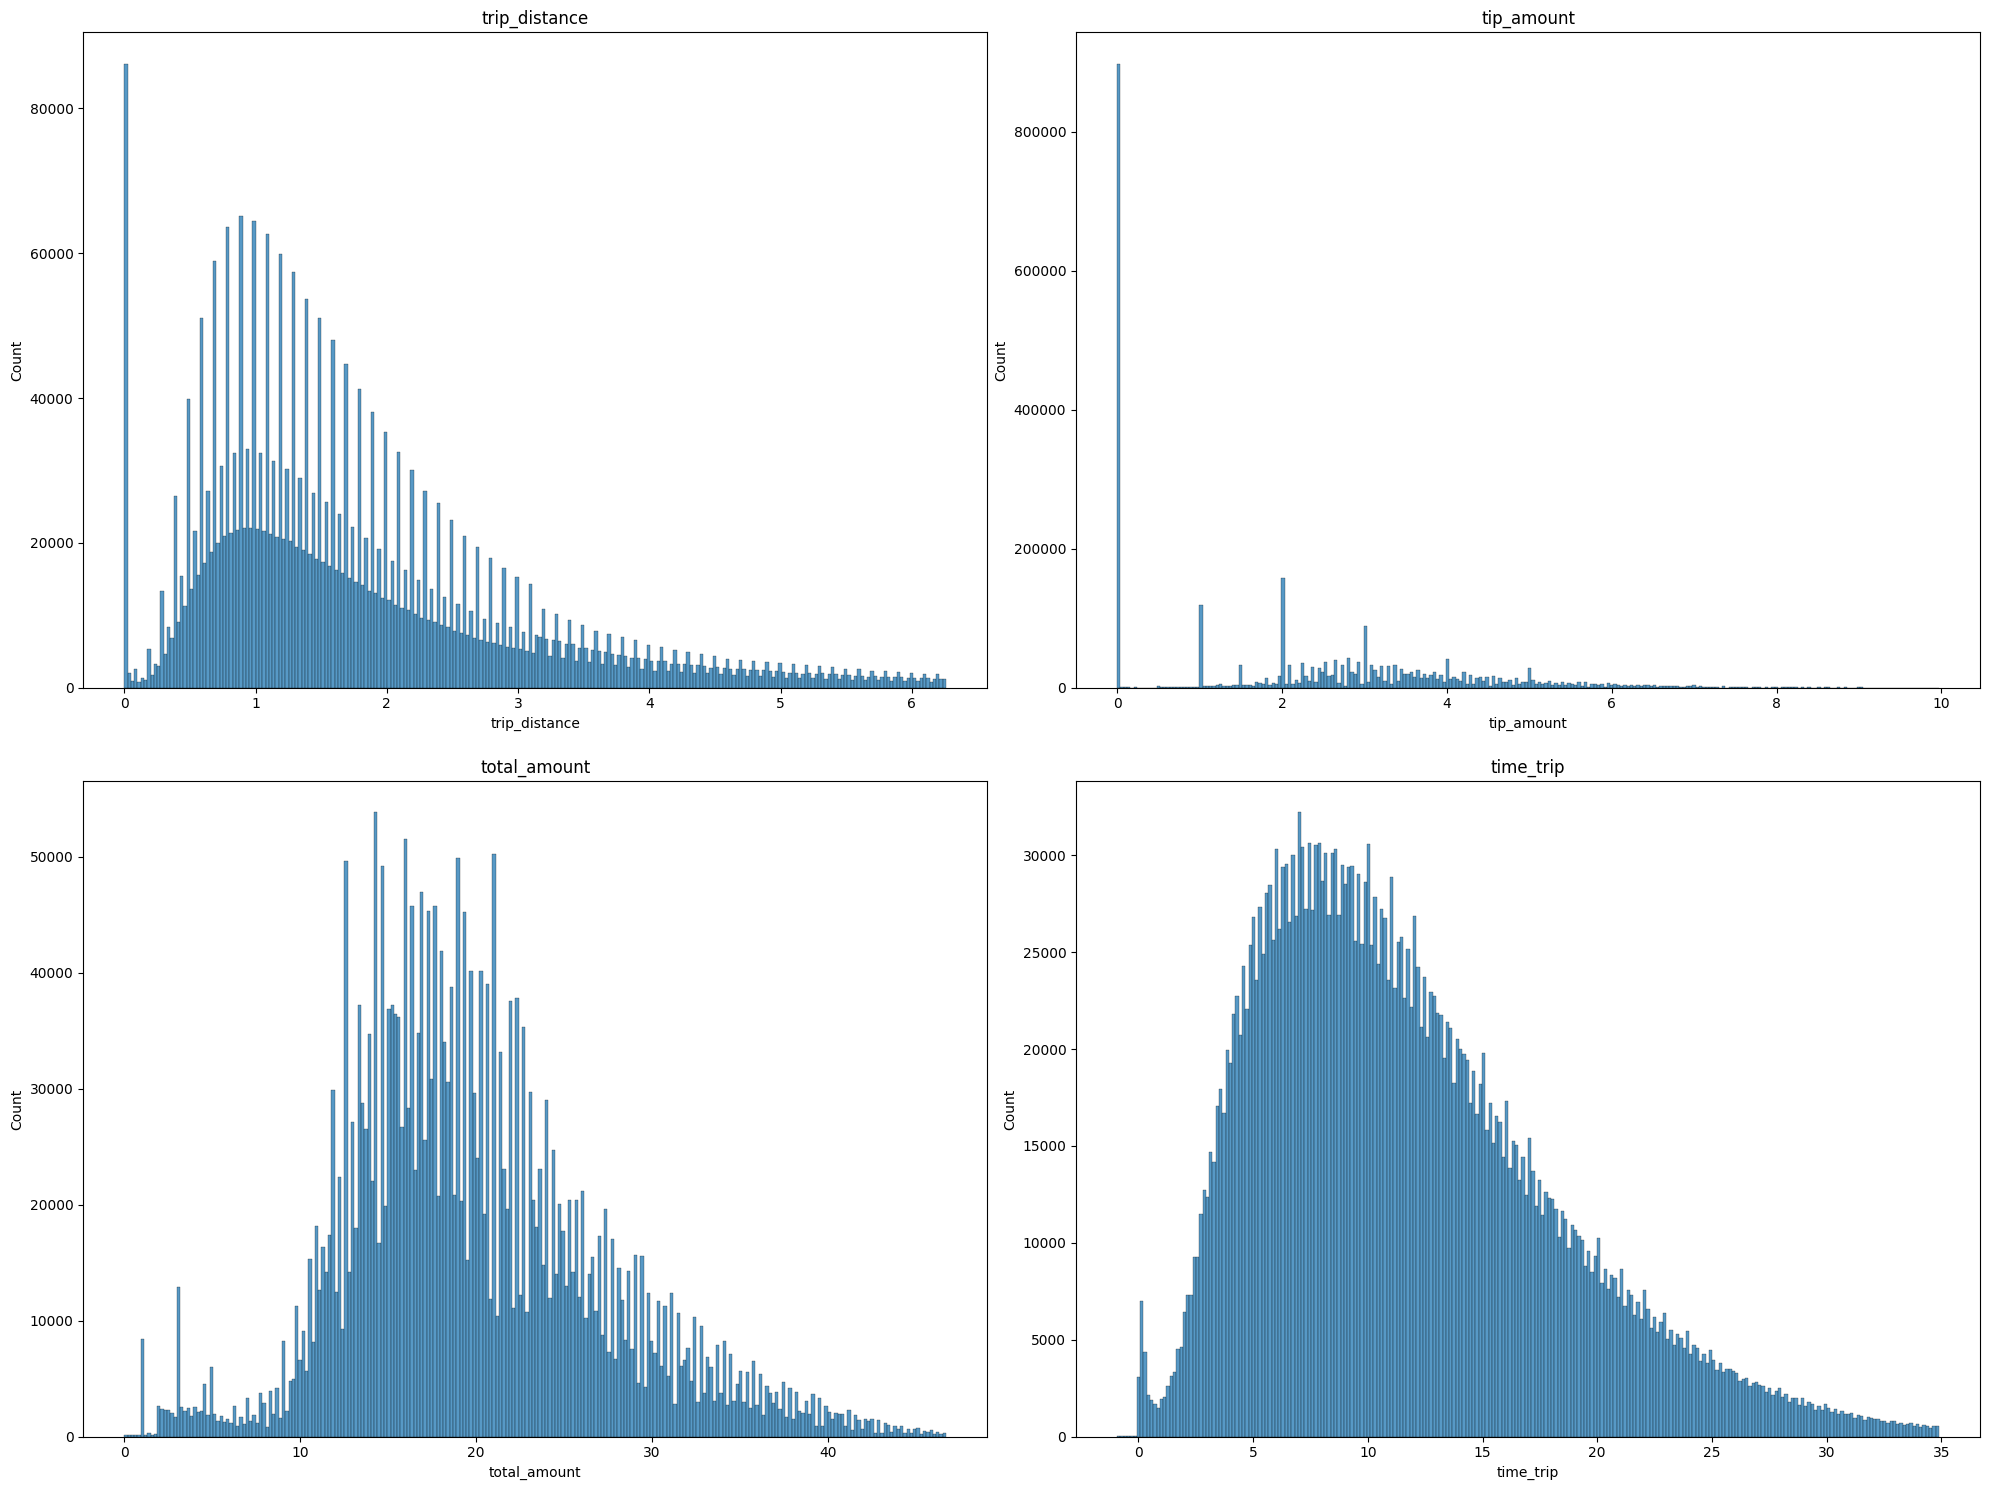

In [25]:
numeric_cols = clean_rides.select_dtypes(include=[np.number]).columns[:4]

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20,15))
index = 0
axs = axs.flatten()
for i, col in enumerate(numeric_cols):
    axs[i].set_title(col)
    sns.histplot(
        data=clean_rides,
        x=col,
        bins=250,
        ax=axs[i]
    )
plt.tight_layout(w_pad=0.5, h_pad=2)
plt.show()


In [26]:
print("Original rows:", len(rides))
print("Cleaned rows:", len(clean_rides))
print("Rows removed:", len(rides) - len(clean_rides))

Original rows: 3411630
Cleaned rows: 2950058
Rows removed: 461572


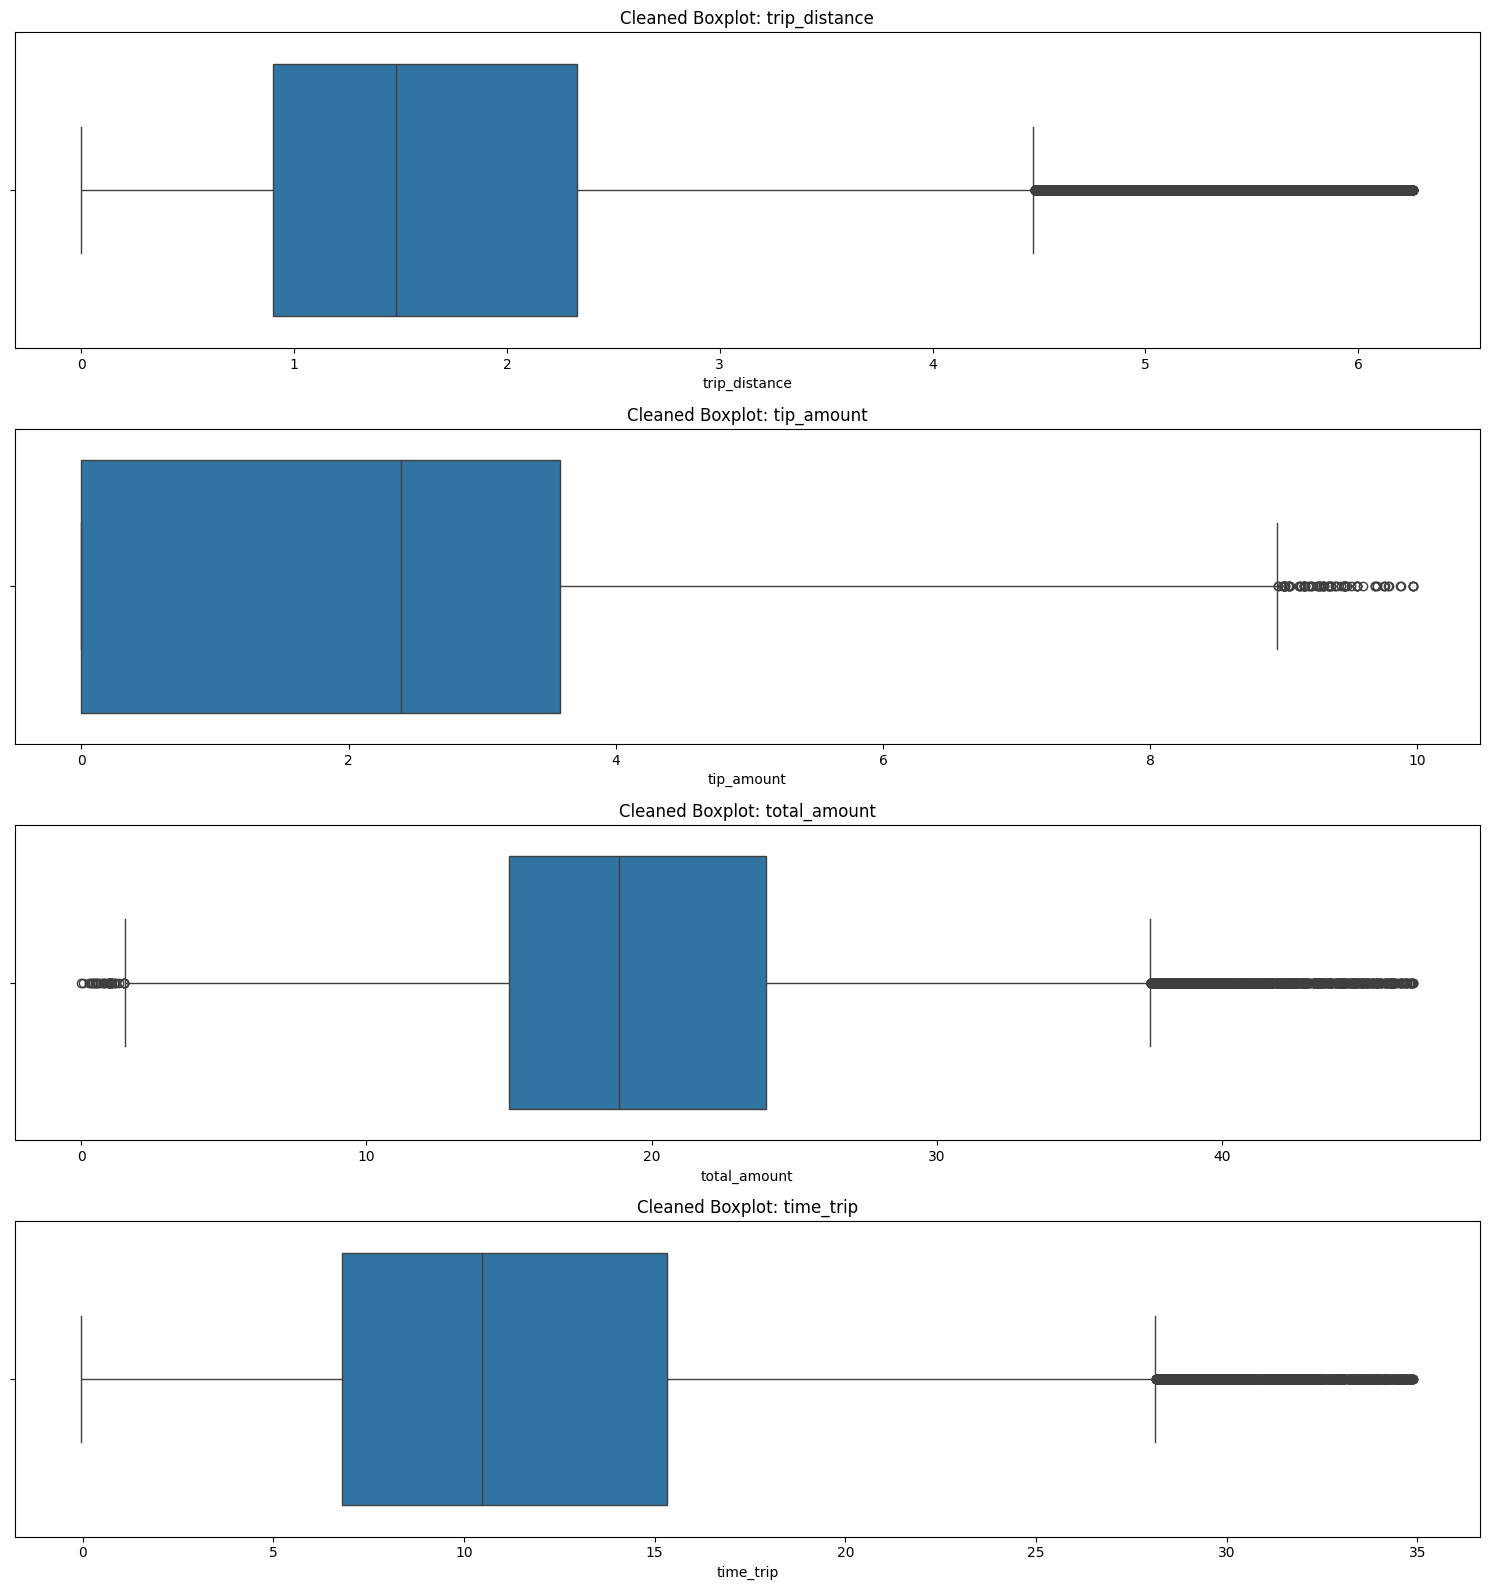

In [27]:
rides_clean_sample = clean_rides[numeric_cols].sample(100_000, random_state=42)

fig, axs = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(15, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=rides_clean_sample, x=col, ax=axs[i])
    axs[i].set_title(f"Cleaned Boxplot: {col}")

plt.tight_layout()
plt.show()

Analysis


In [28]:

trip_monthly = clean_rides.groupby(clean_rides['tpep_pickup_datetime'].dt.date).agg(trip_bydate=('tpep_pickup_datetime', 'count')).reset_index()
trip_monthly['tpep_pickup_datetime'] = pd.to_datetime(trip_monthly['tpep_pickup_datetime'])
trip_monthly['day_of_week'] = trip_monthly['tpep_pickup_datetime'].dt.day_name()
trip_monthly = trip_monthly[trip_monthly.tpep_pickup_datetime	 >= '2025-01-01']
trip_monthly = trip_monthly[trip_monthly.tpep_pickup_datetime	 < '2025-02-01']
trip_monthly.head()


,tpep_pickup_datetime,trip_bydate,day_of_week
1,2025-01-01,68173,Wednesday
2,2025-01-02,67634,Thursday
3,2025-01-03,74962,Friday
4,2025-01-04,81820,Saturday
5,2025-01-05,63025,Sunday


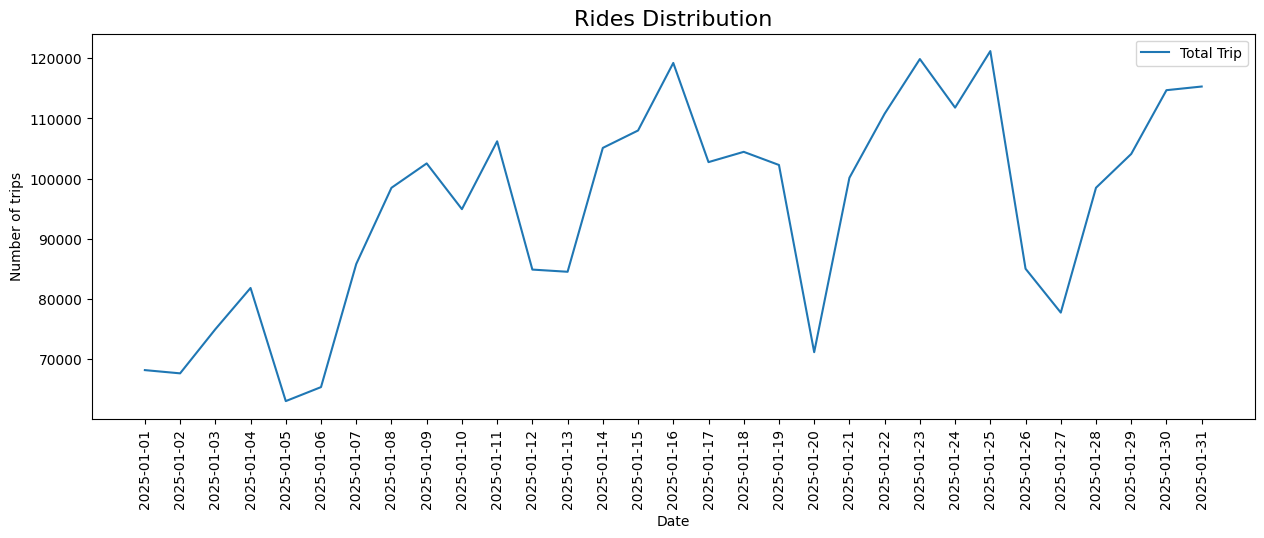

In [29]:
plt.figure(figsize=(15,5))

sns.lineplot(data=trip_monthly,
             x='tpep_pickup_datetime',
             y='trip_bydate',
             label = 'Total Trip')


plt.title('Rides Distribution', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of trips')
plt.xticks(trip_monthly['tpep_pickup_datetime'], rotation=90)

plt.show()

In [30]:
trip_dayly = trip_monthly.groupby('day_of_week').agg(trip_byday=('trip_bydate', 'sum'), day_count=('day_of_week', 'count'), avg_trip=('trip_bydate', 'mean')).reset_index()
trip_dayly

,day_of_week,trip_byday,day_count,avg_trip
0,Friday,499678,5,99935.60
1,Monday,298737,4,74684.25
2,Saturday,413616,4,103404.00
3,Sunday,335169,4,83792.25
4,Thursday,523883,5,104776.60
5,Tuesday,389484,4,97371.00
6,Wednesday,489473,5,97894.60


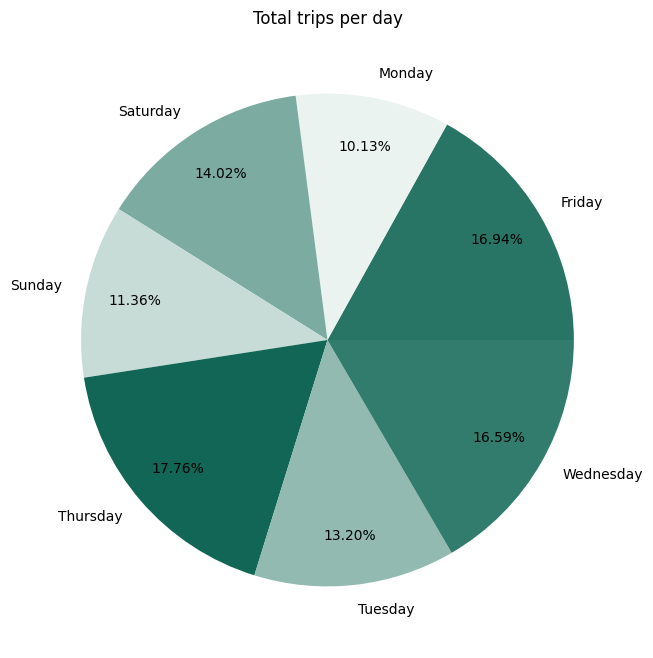

In [31]:
values = trip_dayly['trip_byday'].values
labels = trip_dayly['day_of_week'].values

norm = (values - values.min()) / (values.max() - values.min())

cmap = sns.color_palette("light:#165", as_cmap=True)

colors = cmap(norm)

plt.figure(figsize=(8, 8))
plt.pie(
    values,
    labels=labels,
    autopct='%1.2f%%',
    pctdistance=0.8,
    colors=colors,
)
plt.title("Total trips per day")
plt.show()

In [32]:
agg = rides['time_day'].value_counts().reset_index()
agg.columns = ['time_day', 'count']
agg

,time_day,count
0,Afternoon,1224490
1,Evening,1187917
2,Morning,734426
3,Night,264797


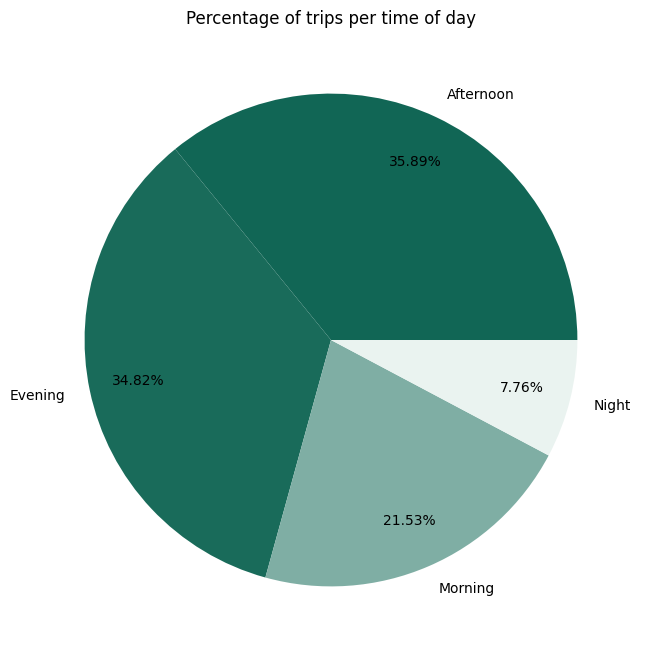

In [33]:
values = agg['count'].values
labels = agg['time_day'].values

norm = (values - values.min()) / (values.max() - values.min())

cmap = sns.color_palette("light:#165", as_cmap=True)

colors = cmap(norm)

plt.figure(figsize=(8, 8))
plt.pie(
    values,
    labels=labels,
    autopct='%1.2f%%',
    pctdistance=0.8,
    colors=colors,
)
plt.title("Percentage of trips per time of day")
plt.show()

In [34]:
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
cross = pd.crosstab(index=clean_rides['tpep_pickup_datetime'].dt.day_name(), columns=clean_rides['tpep_pickup_datetime'].dt.hour, margins=True).reindex(day_order)
cross = cross.iloc[:,:-1].reset_index().melt(id_vars='tpep_pickup_datetime', var_name='hour', value_name='trips')
cross

,tpep_pickup_datetime,hour,trips
0,Sunday,0,24110
1,Monday,0,5032
2,Tuesday,0,2927
3,Wednesday,0,9571
4,Thursday,0,5464
...,...,...,...
163,Tuesday,23,8849
164,Wednesday,23,11806
165,Thursday,23,18947
166,Friday,23,30152


/tmp/ipython-input-1463602073.py:4: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.lineplot(data=cross,


Text(0, 0.5, 'Total')

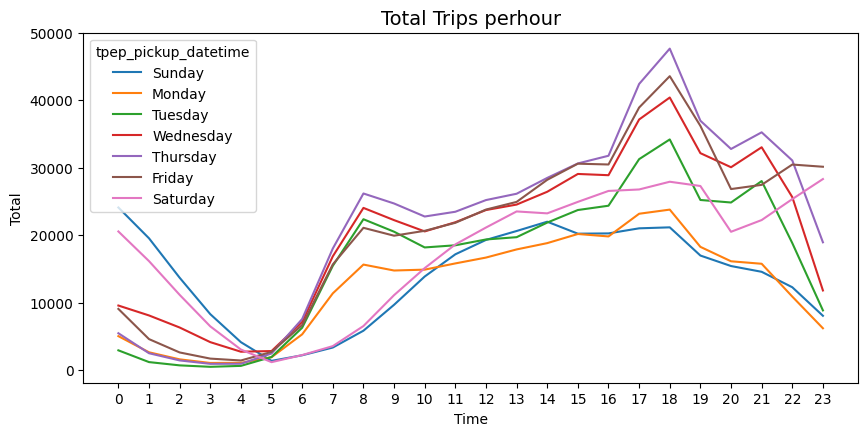

In [35]:
plt.figure(figsize=(10,10))
colors = sns.color_palette()
plt.subplot(2, 1, 1)
sns.lineplot(data=cross,
             x='hour',
             y='trips',
             hue='tpep_pickup_datetime',
             palette=colors)

plt.title('Total Trips perhour', fontsize=14)
plt.xlabel('Time')
plt.xticks(np.arange(0,24,1))
plt.ylabel('Total')

In [36]:

agg_zone = clean_rides[clean_rides["pu_loc_borough"] == "Manhattan"].groupby('pu_loc_zone').agg(count=('pu_loc_zone', 'count'), fare_avg=('total_amount', 'mean')).sort_values(by='count', ascending=False).reset_index()
agg_zone

,pu_loc_zone,count,fare_avg
0,Midtown Center,156573,20.680768
1,Upper East Side South,155971,18.436784
2,Upper East Side North,147474,18.629702
3,Penn Station/Madison Sq West,109419,21.502238
4,Times Sq/Theatre District,109301,20.654509
...,...,...,...
61,Roosevelt Island,122,22.369672
62,Randalls Island,29,26.500345
63,Marble Hill,28,17.963929
64,Inwood Hill Park,12,20.973333


/tmp/ipython-input-60305500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


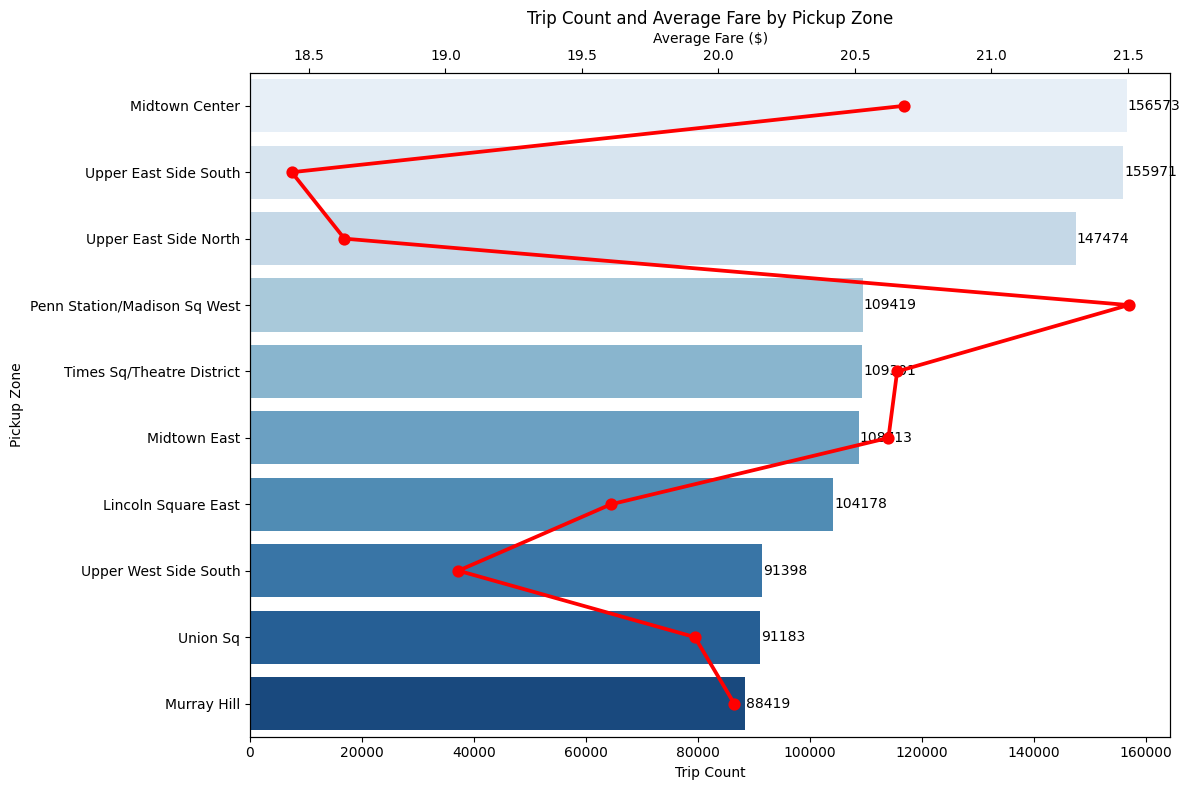

In [37]:
top10 = agg_zone.head(10)

fig, ax1 = plt.subplots(figsize=(12, 8))

# --- First axis: trip counts ---
sns.barplot(
    data=top10,
    y="pu_loc_zone",
    x="count",
    palette="Blues",
    ax=ax1
)

ax1.set_xlabel("Trip Count")
ax1.set_ylabel("Pickup Zone")
ax1.set_title("Trip Count and Average Fare by Pickup Zone")

# annotate count labels
for i, bar in enumerate(ax1.patches):
    ax1.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{int(top10['count'].iloc[i])}",
        va='center'
    )

# --- Second axis: fare metric ---
ax2 = ax1.twiny()

sns.pointplot(
    data=top10,
    y="pu_loc_zone",
    x="fare_avg",   # <-- whatever your fare column is
    color="red",
    ax=ax2
)

ax2.set_xlabel("Average Fare ($)")

plt.tight_layout()
plt.show()

/tmp/ipython-input-85801994.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=agg_zone.head(10),


Text(0, 0.5, 'Total trips')

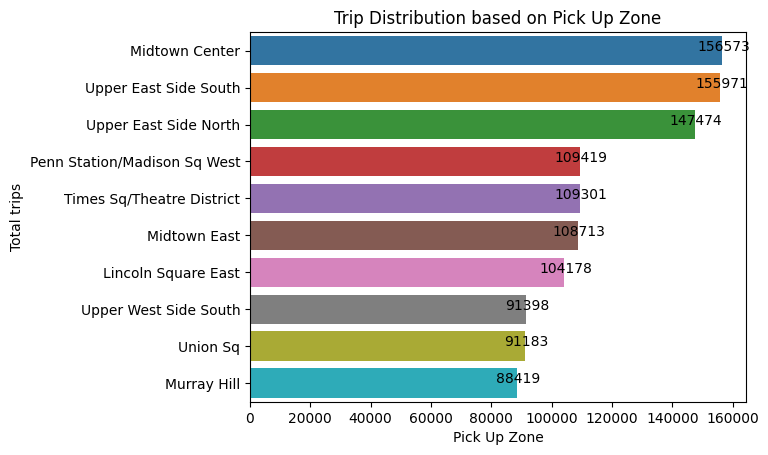

In [38]:
bars = sns.barplot(data=agg_zone.head(10),
                   y='pu_loc_zone',
                   x='count',
                   palette=colors)
for idx, bar in enumerate(bars.patches):
    y_value = bar.get_y() + bar.get_height() / 2
    x_value = bar.get_width() + 400
    label = "{:.0f}".format(agg_zone['count'].iloc[idx])
    plt.text(x_value, y_value, label, ha='center')

plt.title('Trip Distribution based on Pick Up Zone')
plt.xlabel('Pick Up Zone')
plt.ylabel('Total trips')


In [39]:
clean_copy = clean_rides.copy()
clean_copy["ztz"] = clean_copy["pu_loc_zone"]+"-"+clean_copy["do_loc_zone"]
print(clean_copy.head())
agg_zone = clean_copy[clean_copy["pu_loc_borough"] == "Manhattan"].groupby('ztz').agg(count=('ztz', 'count'), fare_avg=('total_amount', 'mean')).sort_values(by='count', ascending=False).reset_index()
agg_zone

  tpep_pickup_datetime tpep_dropoff_datetime  trip_distance  tip_amount  \
0  2025-01-01 00:18:38   2025-01-01 00:26:59           1.60        3.00   
1  2025-01-01 00:32:40   2025-01-01 00:35:13           0.50        2.02   
2  2025-01-01 00:44:04   2025-01-01 00:46:01           0.60        2.00   
3  2025-01-01 00:14:27   2025-01-01 00:20:01           0.52        0.00   
4  2025-01-01 00:21:34   2025-01-01 00:25:06           0.66        0.00   

   total_amount time_day   day_week day_category  time_trip time_bucket  \
0         18.00    Night  Wednesday      Weekday   8.350000      <10min   
1         12.12    Night  Wednesday      Weekday   2.550000      <10min   
2         12.10    Night  Wednesday      Weekday   1.950000      <10min   
3          9.70    Night  Wednesday      Weekday   5.566667      <10min   
4          8.30    Night  Wednesday      Weekday   3.533333      <10min   

  distance_bucket amount_bucket  payment_cat                    pu_loc_zone  \
0            <2mi  

,ztz,count,fare_avg
0,Upper East Side South-Upper East Side North,24539,15.514073
1,Upper East Side North-Upper East Side South,21626,15.657194
2,Upper East Side North-Upper East Side North,17559,12.903558
3,Upper East Side South-Upper East Side South,16731,13.490863
4,Midtown Center-Upper East Side South,11275,17.495367
...,...,...,...
5855,Yorkville West-Soundview/Bruckner,1,37.650000
5856,East Village-Kew Gardens,1,24.900000
5857,Seaport-Sunset Park West,1,39.480000
5858,Yorkville West-West Farms/Bronx River,1,30.000000


/tmp/ipython-input-3315599432.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=agg_zone.head(10),


Text(0, 0.5, 'Total trips')

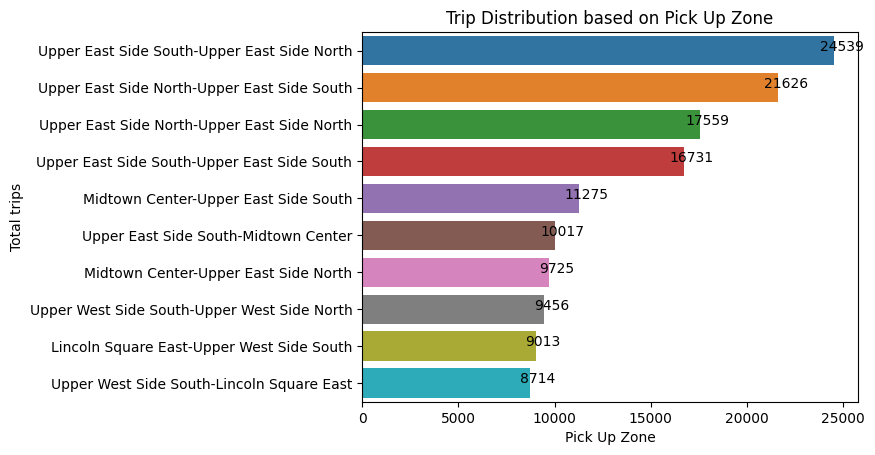

In [40]:
bars = sns.barplot(data=agg_zone.head(10),
                   y='ztz',
                   x='count',
                   palette=colors)
for idx, bar in enumerate(bars.patches):
    y_value = bar.get_y() + bar.get_height() / 2
    x_value = bar.get_width() + 400
    label = "{:.0f}".format(agg_zone['count'].iloc[idx])
    plt.text(x_value, y_value, label, ha='center')

plt.title('Trip Distribution based on Pick Up Zone')
plt.xlabel('Pick Up Zone')
plt.ylabel('Total trips')

/tmp/ipython-input-2907801597.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


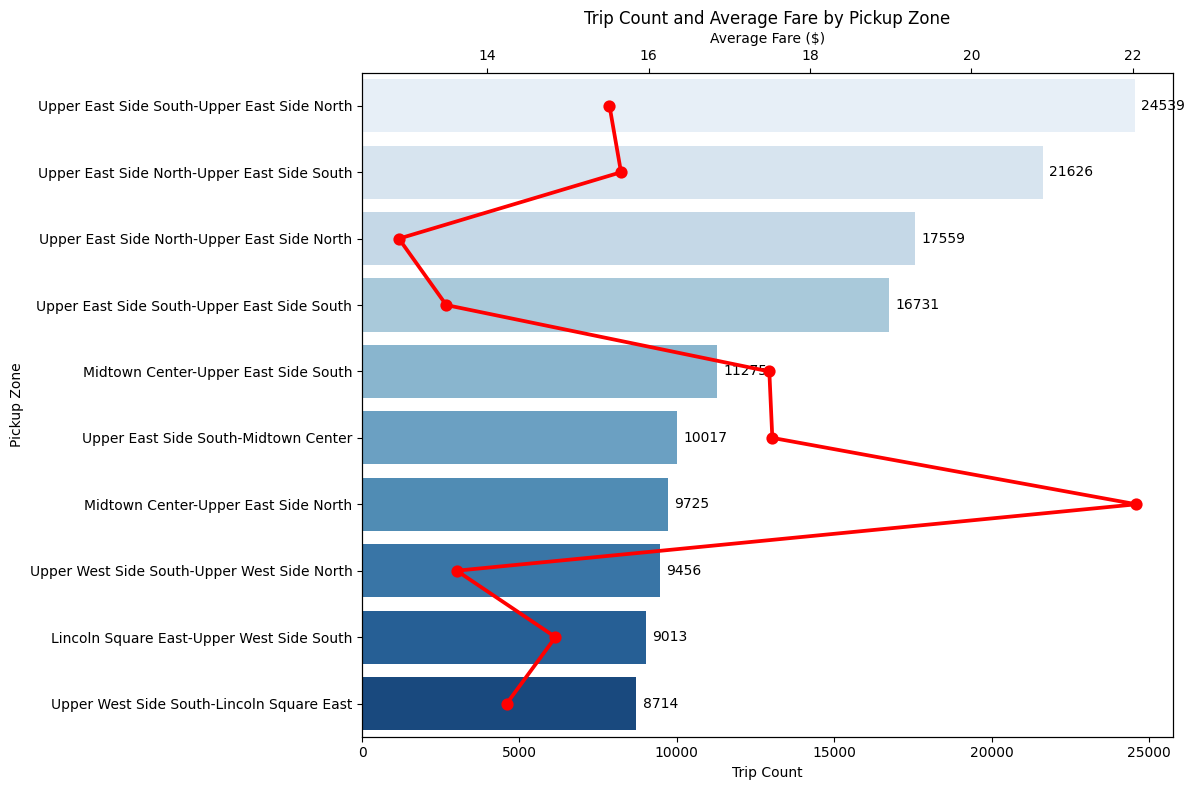

In [41]:
top10 = agg_zone.head(10)

fig, ax1 = plt.subplots(figsize=(12, 8))

# --- First axis: trip counts ---
sns.barplot(
    data=top10,
    y="ztz",
    x="count",
    palette="Blues",
    ax=ax1
)

ax1.set_xlabel("Trip Count")
ax1.set_ylabel("Pickup Zone")
ax1.set_title("Trip Count and Average Fare by Pickup Zone")

# annotate count labels
for i, bar in enumerate(ax1.patches):
    ax1.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{int(top10['count'].iloc[i])}",
        va='center'
    )

# --- Second axis: fare metric ---
ax2 = ax1.twiny()

sns.pointplot(
    data=top10,
    y="ztz",
    x="fare_avg",   # <-- whatever your fare column is
    color="red",
    ax=ax2
)

ax2.set_xlabel("Average Fare ($)")

plt.tight_layout()
plt.show()

Model evaluation

In [50]:
rides = pd.read_parquet('/content/data_tlc/raw/rides_2025_01.parquet')
rides = rides[['tpep_pickup_datetime','PULocationID']]
rides['pu_hour'] = rides['tpep_pickup_datetime'].dt.floor("h")
agg_rides = rides.groupby(['pu_hour', 'PULocationID']).size().reset_index()
agg_rides.rename(columns={0: 'count_rides'}, inplace=True)
agg_rides.head()

,pu_hour,PULocationID,count_rides
0,2024-12-31 20:00:00,48,1
1,2024-12-31 20:00:00,246,1
2,2024-12-31 20:00:00,249,1
3,2024-12-31 21:00:00,42,1
4,2024-12-31 21:00:00,141,1


In [51]:
agg_rides = agg_rides[agg_rides.pu_hour >= '2025-01-01']
agg_rides = agg_rides[agg_rides.pu_hour < '2025-02-01']
agg_rides

,pu_hour,PULocationID,count_rides
18,2025-01-01 00:00:00,4,28
19,2025-01-01 00:00:00,7,12
20,2025-01-01 00:00:00,9,1
21,2025-01-01 00:00:00,10,1
22,2025-01-01 00:00:00,12,1
...,...,...,...
97027,2025-01-31 23:00:00,261,35
97028,2025-01-31 23:00:00,262,29
97029,2025-01-31 23:00:00,263,133
97030,2025-01-31 23:00:00,264,20


In [52]:
agg_rides["pu_hour"] = pd.to_datetime(agg_rides["pu_hour"])
full_hours = pd.date_range(
        agg_rides["pu_hour"].min(),
        agg_rides["pu_hour"].max(),
        freq="h"
    )
full_hours

DatetimeIndex(['2025-01-01 00:00:00', '2025-01-01 01:00:00',
               '2025-01-01 02:00:00', '2025-01-01 03:00:00',
               '2025-01-01 04:00:00', '2025-01-01 05:00:00',
               '2025-01-01 06:00:00', '2025-01-01 07:00:00',
               '2025-01-01 08:00:00', '2025-01-01 09:00:00',
               ...
               '2025-01-31 14:00:00', '2025-01-31 15:00:00',
               '2025-01-31 16:00:00', '2025-01-31 17:00:00',
               '2025-01-31 18:00:00', '2025-01-31 19:00:00',
               '2025-01-31 20:00:00', '2025-01-31 21:00:00',
               '2025-01-31 22:00:00', '2025-01-31 23:00:00'],
              dtype='datetime64[ns]', length=744, freq='h')

In [53]:
all_locations = agg_rides["PULocationID"].unique()
all_locations

array([  4,   7,   9,  10,  12,  13,  14,  15,  16,  17,  18,  22,  24,
        25,  26,  28,  33,  36,  37,  39,  40,  41,  42,  43,  45,  47,
        48,  49,  50,  51,  52,  53,  55,  56,  60,  61,  64,  65,  66,
        68,  69,  70,  71,  72,  74,  75,  76,  78,  79,  80,  81,  82,
        83,  87,  88,  89,  90,  91,  92,  93,  95,  97,  98, 100, 101,
       106, 107, 112, 113, 114, 116, 123, 124, 125, 126, 127, 129, 130,
       131, 132, 133, 134, 137, 138, 140, 141, 142, 143, 144, 145, 146,
       148, 149, 150, 151, 152, 156, 158, 159, 160, 161, 162, 163, 164,
       166, 168, 170, 174, 175, 177, 179, 180, 181, 185, 186, 188, 189,
       191, 195, 197, 198, 202, 205, 209, 210, 211, 213, 215, 216, 218,
       219, 220, 221, 222, 223, 224, 225, 226, 228, 229, 231, 232, 233,
       234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 246, 247,
       249, 252, 255, 256, 257, 258, 260, 261, 262, 263, 264, 265,   3,
        11,  20,  21,  29,  32,  34,  35,  54,  58,  62,  63,  7

In [56]:
full_grid = (
        pd.MultiIndex.from_product(
            [full_hours, all_locations],
            names=["pu_hour", "PULocationID"]
        )
        .to_frame()
        .reset_index(drop=True)
    )
merged = full_grid.merge(
        agg_rides,
        on=["pu_hour", "PULocationID"],
        how="left"
    )
merged

,pu_hour,PULocationID,count_rides
0,2025-01-01 00:00:00,4,28.0
1,2025-01-01 00:00:00,7,12.0
2,2025-01-01 00:00:00,9,1.0
3,2025-01-01 00:00:00,10,1.0
4,2025-01-01 00:00:00,12,1.0
...,...,...,...
194179,2025-01-31 23:00:00,84,NaN
194180,2025-01-31 23:00:00,30,NaN
194181,2025-01-31 23:00:00,111,NaN
194182,2025-01-31 23:00:00,204,NaN


In [57]:
merged["count_rides"] = merged["count_rides"].fillna(0)
merged

,pu_hour,PULocationID,count_rides
0,2025-01-01 00:00:00,4,28.0
1,2025-01-01 00:00:00,7,12.0
2,2025-01-01 00:00:00,9,1.0
3,2025-01-01 00:00:00,10,1.0
4,2025-01-01 00:00:00,12,1.0
...,...,...,...
194179,2025-01-31 23:00:00,84,0.0
194180,2025-01-31 23:00:00,30,0.0
194181,2025-01-31 23:00:00,111,0.0
194182,2025-01-31 23:00:00,204,0.0


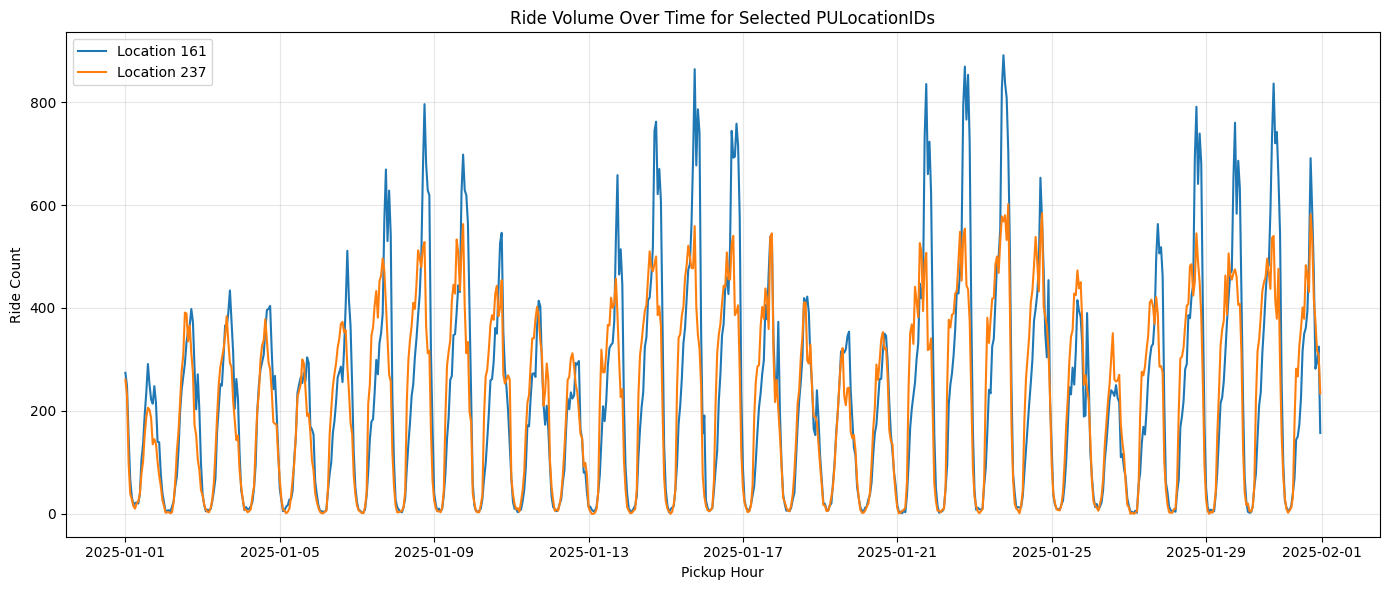

In [65]:
plt.figure(figsize=(14, 6))
df_plot = merged[merged["PULocationID"].isin([237, 161])]
for loc_id in df_plot["PULocationID"].unique():
    subset = df_plot[df_plot["PULocationID"] == loc_id]
    plt.plot(subset["pu_hour"], subset["count_rides"], label=f"Location {loc_id}")


plt.xlabel("Pickup Hour")
plt.ylabel("Ride Count")
plt.title("Ride Volume Over Time for Selected PULocationIDs")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
data_one_location = merged.loc[merged.PULocationID == 161].reset_index(drop=True)


,pu_hour,PULocationID,count_rides
0,2025-01-01 00:00:00,161,274.0
1,2025-01-01 01:00:00,161,248.0
2,2025-01-01 02:00:00,161,150.0
3,2025-01-01 03:00:00,161,67.0
4,2025-01-01 04:00:00,161,33.0
5,2025-01-01 05:00:00,161,16.0
6,2025-01-01 06:00:00,161,21.0
7,2025-01-01 07:00:00,161,22.0
8,2025-01-01 08:00:00,161,20.0
9,2025-01-01 09:00:00,161,38.0


In [12]:
def get_lag_indices(data, n_features, step_size):
    stop_pos = len(data) - 1

    indices = []
    for start in range(0, stop_pos - n_features, step_size):
        first = start
        mid = start + n_features
        last = start + n_features + 1

        if last > stop_pos:
            break

        indices.append((first, mid, last))

    return indices

n_features = 24
step_size = 1



In [ ]:
indices = get_lag_indices(data_one_location, n_features, step_size)
indices[:5]

In [13]:
import numpy as np

def build_xy(data_one_location, indices, n_features):
    x_list = []
    y_list = []
    pu_hrs = []

    rides = data_one_location["count_rides"].values
    hours = data_one_location["pu_hour"].values

    for first, mid, last in indices:
        x_list.append(rides[first:mid])
        y_list.append(rides[mid])
        pu_hrs.append(hours[mid])

    x = np.array(x_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)

    return x, y, pu_hrs

In [73]:
x, y, pu_hr  = build_xy(data_one_location, indices, n_features)
features_one_location = pd.DataFrame(x,columns=[f'rides_prev_{i+1}_hr' for i in reversed(range(n_features))])
features_one_location.head()

,rides_prev_24_hr,rides_prev_23_hr,rides_prev_22_hr,rides_prev_21_hr,rides_prev_20_hr,rides_prev_19_hr,rides_prev_18_hr,rides_prev_17_hr,rides_prev_16_hr,rides_prev_15_hr,...,rides_prev_10_hr,rides_prev_9_hr,rides_prev_8_hr,rides_prev_7_hr,rides_prev_6_hr,rides_prev_5_hr,rides_prev_4_hr,rides_prev_3_hr,rides_prev_2_hr,rides_prev_1_hr
0,274.0,248.0,150.0,67.0,33.0,16.0,21.0,22.0,20.0,38.0,...,291.0,251.0,222.0,214.0,248.0,216.0,140.0,139.0,78.0,41.0
1,248.0,150.0,67.0,33.0,16.0,21.0,22.0,20.0,38.0,105.0,...,251.0,222.0,214.0,248.0,216.0,140.0,139.0,78.0,41.0,22.0
2,150.0,67.0,33.0,16.0,21.0,22.0,20.0,38.0,105.0,136.0,...,222.0,214.0,248.0,216.0,140.0,139.0,78.0,41.0,22.0,5.0
3,67.0,33.0,16.0,21.0,22.0,20.0,38.0,105.0,136.0,192.0,...,214.0,248.0,216.0,140.0,139.0,78.0,41.0,22.0,5.0,6.0
4,33.0,16.0,21.0,22.0,20.0,38.0,105.0,136.0,192.0,236.0,...,248.0,216.0,140.0,139.0,78.0,41.0,22.0,5.0,6.0,7.0


In [74]:
targets_one_location = pd.DataFrame(y, columns=['target_rides_next_hr'])
targets_one_location.head()

,target_rides_next_hr
0,22.0
1,5.0
2,6.0
3,7.0
4,4.0


In [5]:
from datetime import datetime, timedelta

def validate_dates(rides, year, month):

    month_start = f"{year}-{month:02d}-01"
    next_month_start = f"{year}-{month+1:02d}-01" if month < 12 else f"{year+1}-01-01"
    rides = rides[rides.tpep_pickup_datetime >= month_start]
    rides = rides[rides.tpep_pickup_datetime < next_month_start]
    return rides

def load_raw_data(year, month, prior_months=12):

    rides = pd.DataFrame()
    current_date = datetime(year, month, 1)

    for n in range(prior_months):
        current_year = current_date.year
        current_month = current_date.month
        name_file = f"rides_{current_year}_{current_month:02d}.parquet"
        local_file = TLC_DATA_DIR / name_file

        if local_file.exists():
            print(f" {name_file} is present")
        else:
            try:
                print(f"Downloading  {name_file}")
                get_tlc_data(current_year, current_month)
            except:
                print(f"not found {name_file}")
                current_date -= timedelta(weeks=4)
                continue

        rides_month = pd.read_parquet(local_file)
        rides_month = rides_month[["tpep_pickup_datetime", "PULocationID"]]
        rides_month = validate_dates(
            rides_month, current_year, current_month
        )
        rides = pd.concat([rides, rides_month])
        current_date -= timedelta(weeks=4)
    return rides

rides = load_raw_data(2025, 11)
rides

not found rides_2025_11.parquet
not found rides_2025_10.parquet
 rides_2025_09.parquet is present
 rides_2025_08.parquet is present
 rides_2025_07.parquet is present
 rides_2025_06.parquet is present
 rides_2025_05.parquet is present
 rides_2025_04.parquet is present
 rides_2025_03.parquet is present
 rides_2025_02.parquet is present
 rides_2025_01.parquet is present
 rides_2024_12.parquet is present


,tpep_pickup_datetime,PULocationID
0,2025-09-01 00:19:20,138
1,2025-09-01 00:15:20,93
2,2025-09-01 00:06:07,68
3,2025-09-01 00:49:47,234
4,2025-09-01 00:05:00,230
...,...,...
3668366,2024-12-31 23:32:00,16
3668367,2024-12-31 23:05:00,252
3668368,2024-12-31 23:03:16,181
3668369,2024-12-31 23:15:33,165


In [8]:
def add_missing_data(agg_rides) :

    all_locations = agg_rides["PULocationID"].unique()
    full_hours = pd.date_range(
        agg_rides["pu_hour"].min(),
        agg_rides["pu_hour"].max(),
        freq="h"
    )
    print(full_hours)

    full_grid = (
        pd.MultiIndex.from_product(
            [full_hours, all_locations],
            names=["pu_hour", "PULocationID"]
        )
        .to_frame()
        .reset_index(drop=True)
    )
    merged = full_grid.merge(
            agg_rides,
            on=["pu_hour", "PULocationID"],
            how="left"
        )
    merged["count_rides"] = merged["count_rides"].fillna(0)
    return merged


def transform_data(rides):


    rides["pu_hour"] = rides["tpep_pickup_datetime"].dt.floor("h")
    agg_rides = rides.groupby(["pu_hour", "PULocationID"]).size().reset_index()
    agg_rides.rename(columns={0: "count_rides"}, inplace=True)
    print(agg_rides)
    agg_all_rides = add_missing_data(agg_rides)
    return agg_all_rides


rides = transform_data(rides)
rides

                    pu_hour  PULocationID  count_rides
0       2024-12-01 00:00:00             4           39
1       2024-12-01 00:00:00             7            9
2       2024-12-01 00:00:00            10            4
3       2024-12-01 00:00:00            13            1
4       2024-12-01 00:00:00            17            1
...                     ...           ...          ...
1156772 2025-09-30 23:00:00           261           14
1156773 2025-09-30 23:00:00           262           12
1156774 2025-09-30 23:00:00           263           49
1156775 2025-09-30 23:00:00           264            3
1156776 2025-09-30 23:00:00           265            1

[1156777 rows x 3 columns]
DatetimeIndex(['2024-12-01 00:00:00', '2024-12-01 01:00:00',
               '2024-12-01 02:00:00', '2024-12-01 03:00:00',
               '2024-12-01 04:00:00', '2024-12-01 05:00:00',
               '2024-12-01 06:00:00', '2024-12-01 07:00:00',
               '2024-12-01 08:00:00', '2024-12-01 09:00:00',
       

,pu_hour,PULocationID,count_rides
0,2024-12-01 00:00:00,4,39.0
1,2024-12-01 00:00:00,7,9.0
2,2024-12-01 00:00:00,10,4.0
3,2024-12-01 00:00:00,13,1.0
4,2024-12-01 00:00:00,17,1.0
...,...,...,...
1911547,2025-09-30 23:00:00,176,0.0
1911548,2025-09-30 23:00:00,5,0.0
1911549,2025-09-30 23:00:00,199,0.0
1911550,2025-09-30 23:00:00,84,0.0


In [14]:
def create_training_data(data, n_features, step_size):

    location_ids = data["PULocationID"].unique()
    features = pd.DataFrame()
    targets = pd.DataFrame()
    for location_id in location_ids:
        data_one_loc = data.loc[
            data.PULocationID == location_id, ["pu_hour", "count_rides"]
        ]
        indices = get_lag_indices(data_one_loc, n_features, step_size)
        x, y, pu_hrs = build_xy(data_one_loc, indices, n_features)
        features_one_location = pd.DataFrame(x,columns=[f'rides_prev_{i+1}_hr' for i in reversed(range(n_features))])
        features_one_location["pu_hour"] = pu_hrs
        features_one_location["PULocationID"] = location_id
        targets_one_location = pd.DataFrame(y, columns=['target_rides_next_hr'])

        features = pd.concat([features, features_one_location])
        targets = pd.concat([targets, targets_one_location])

    features.reset_index(inplace=True, drop=True)
    targets.reset_index(inplace=True, drop=True)

    return features, targets["target_rides_next_hr"]


X, y = create_training_data(rides, 24, 1)



In [15]:
print(f'{X.shape=}')
print(f'{y.shape=}')

X.shape=(1905002, 26)
y.shape=(1905002,)


In [16]:
TRAINING_DATA_DIR = DATA_DIR / "train"
if not Path(TRAINING_DATA_DIR).exists():
  os.mkdir(TRAINING_DATA_DIR)

training_data = X
training_data['target_rides_next_hours'] = y
training_data.to_parquet(TRAINING_DATA_DIR / 'training_data.parquet')

In [17]:
def train_test_data_split(df, cutoff_date, target_column):

    train_data = df[df.pu_hour < cutoff_date].reset_index(drop=True)

    test_data = df[df.pu_hour >= cutoff_date].reset_index(drop=True)
    X_train = train_data.drop(columns=[target_column])
    y_train = train_data[target_column]
    X_test = test_data.drop(columns=[target_column])
    y_test = test_data[target_column]

    return X_train, y_train, X_test, y_test

In [18]:
X_train, y_train, X_test, y_test = train_test_data_split(training_data, datetime(2025,7,28),'target_rides_next_hours')
print(f'{X_train.shape=}')
print(f'{y_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_test.shape=}')

hola
cool
cool2
X_train.shape=(1496544, 26)
y_train.shape=(1496544,)
X_test.shape=(408458, 26)
y_test.shape=(408458,)


In [19]:
X_train

,rides_prev_24_hr,rides_prev_23_hr,rides_prev_22_hr,rides_prev_21_hr,rides_prev_20_hr,rides_prev_19_hr,rides_prev_18_hr,rides_prev_17_hr,rides_prev_16_hr,rides_prev_15_hr,...,rides_prev_8_hr,rides_prev_7_hr,rides_prev_6_hr,rides_prev_5_hr,rides_prev_4_hr,rides_prev_3_hr,rides_prev_2_hr,rides_prev_1_hr,pu_hour,PULocationID
0,39.0,42.0,21.0,16.0,1.0,0.0,1.0,4.0,2.0,1.0,...,3.0,4.0,5.0,3.0,2.0,2.0,4.0,3.0,2024-12-02 00:00:00,4
1,42.0,21.0,16.0,1.0,0.0,1.0,4.0,2.0,1.0,5.0,...,4.0,5.0,3.0,2.0,2.0,4.0,3.0,1.0,2024-12-02 01:00:00,4
2,21.0,16.0,1.0,0.0,1.0,4.0,2.0,1.0,5.0,5.0,...,5.0,3.0,2.0,2.0,4.0,3.0,1.0,0.0,2024-12-02 02:00:00,4
3,16.0,1.0,0.0,1.0,4.0,2.0,1.0,5.0,5.0,1.0,...,3.0,2.0,2.0,4.0,3.0,1.0,0.0,0.0,2024-12-02 03:00:00,4
4,1.0,0.0,1.0,4.0,2.0,1.0,5.0,5.0,1.0,1.0,...,2.0,2.0,4.0,3.0,1.0,0.0,0.0,0.0,2024-12-02 04:00:00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1496539,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-27 19:00:00,105
1496540,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-27 20:00:00,105
1496541,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-27 21:00:00,105
1496542,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-27 22:00:00,105


In [20]:
lag_features = [c for c in X_train.columns if c.startswith('r')]
X_train_ = X_train[lag_features]

In [21]:
import lightgbm as lgb
model = lgb.LGBMRegressor()
model.fit(X_train_, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.162467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 1496544, number of used features: 24
[LightGBM] [Info] Start training from score 20.721328


LGBMRegressor()

In [23]:
from sklearn.metrics import mean_absolute_error
X_test_ = X_test[lag_features]
predictions = model.predict(X_test_)
mae = mean_absolute_error(y_test, predictions)
mae

3.96115713590982

In [25]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.5 MB/s eta 0:00:00


In [26]:
import numpy as np
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error
import optuna
import warnings
warnings.filterwarnings("ignore")

In [41]:
def tuning(trial: optuna.trial.Trial) -> float:

    hyperparams = {
        "metric": 'mae',
        "verbose": -1,
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "max_depth": trial.suggest_int("max_depth", 2, 16),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.2, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.2, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 3, 100),
    }

    tss = TimeSeriesSplit(n_splits=4)
    scores = []
    for train_index, val_index in tss.split(X_train_):

        X_train_1, X_val_ = X_train_.iloc[train_index, :], X_train_.iloc[val_index,:]
        y_train_, y_val_ = y_train.iloc[train_index], y_train.iloc[val_index]

        moddel = lgb.LGBMRegressor(**hyperparams)
        model.fit(X_train_1, y_train_)

        y_pred = model.predict(X_val_)
        mae = mean_absolute_error(y_val_, y_pred)
        scores.append(mae)

    return np.array(scores).mean()

In [42]:
study = optuna.create_study(direction="minimize")
study.optimize(tuning, n_trials=15)

[I 2025-11-22 17:55:09,173] A new study created in memory with name: no-name-1ce91c0a-430a-44d2-8f70-cc3699a038c1


[LightGBM] [Warning] feature_fraction is set=0.2857541362475273, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2857541362475273
[LightGBM] [Warning] bagging_fraction is set=0.4939496455875332, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4939496455875332
[LightGBM] [Warning] feature_fraction is set=0.2857541362475273, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2857541362475273
[LightGBM] [Warning] bagging_fraction is set=0.4939496455875332, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4939496455875332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.081014 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 299312, number of used features: 24
[LightGBM] [Info] Start training from score 24.844153
[LightGBM] [Warning] feature_fraction is set=0.2857541

[I 2025-11-22 17:55:39,193] Trial 0 finished with value: 4.211272207136518 and parameters: {'num_leaves': 219, 'max_depth': 8, 'feature_fraction': 0.9186645316615327, 'bagging_fraction': 0.817943176768513, 'min_child_samples': 68}. Best is trial 0 with value: 4.211272207136518.


[LightGBM] [Warning] feature_fraction is set=0.2857541362475273, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2857541362475273
[LightGBM] [Warning] bagging_fraction is set=0.4939496455875332, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4939496455875332
[LightGBM] [Warning] feature_fraction is set=0.2857541362475273, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2857541362475273
[LightGBM] [Warning] bagging_fraction is set=0.4939496455875332, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4939496455875332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.082413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 299312, number of used features: 24
[LightGBM] [Info] Start training from score 24.844153
[LightGBM] [Warning] feature_fraction is set=0.2857541

[I 2025-11-22 17:56:08,664] Trial 1 finished with value: 4.211272207136518 and parameters: {'num_leaves': 250, 'max_depth': 10, 'feature_fraction': 0.4794744897805, 'bagging_fraction': 0.232056147197783, 'min_child_samples': 96}. Best is trial 0 with value: 4.211272207136518.


...

[I 2025-11-22 18:01:32,480] Trial 12 finished with value: 4.211272207136518 and parameters: {'num_leaves': 253, 'max_depth': 13, 'feature_fraction': 0.5682664374522868, 'bagging_fraction': 0.8518670026839917, 'min_child_samples': 5}. Best is trial 0 with value: 4.211272207136518.


[LightGBM] [Warning] feature_fraction is set=0.2857541362475273, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2857541362475273
[LightGBM] [Warning] bagging_fraction is set=0.4939496455875332, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4939496455875332
[LightGBM] [Warning] feature_fraction is set=0.2857541362475273, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2857541362475273
[LightGBM] [Warning] bagging_fraction is set=0.4939496455875332, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4939496455875332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 299312, number of used features: 24
[LightGBM] [Info] Start training from score 24.844153
[LightGBM] [Warning] feature_fraction is set=0.2857541

[I 2025-11-22 18:02:07,888] Trial 13 finished with value: 4.211272207136518 and parameters: {'num_leaves': 211, 'max_depth': 16, 'feature_fraction': 0.2552660554357834, 'bagging_fraction': 0.22140225832268823, 'min_child_samples': 63}. Best is trial 0 with value: 4.211272207136518.


[LightGBM] [Warning] feature_fraction is set=0.2857541362475273, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2857541362475273
[LightGBM] [Warning] bagging_fraction is set=0.4939496455875332, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4939496455875332
[LightGBM] [Warning] feature_fraction is set=0.2857541362475273, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2857541362475273
[LightGBM] [Warning] bagging_fraction is set=0.4939496455875332, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4939496455875332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.080121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 299312, number of used features: 24
[LightGBM] [Info] Start training from score 24.844153
[LightGBM] [Warning] feature_fraction is set=0.2857541

[I 2025-11-22 18:02:41,380] Trial 14 finished with value: 4.211272207136518 and parameters: {'num_leaves': 161, 'max_depth': 11, 'feature_fraction': 0.6762431148592833, 'bagging_fraction': 0.8059753213142817, 'min_child_samples': 79}. Best is trial 0 with value: 4.211272207136518.


In [43]:
best_params = study.best_trial.params
best_params

{'num_leaves': 219,
 'max_depth': 8,
 'feature_fraction': 0.9186645316615327,
 'bagging_fraction': 0.817943176768513,
 'min_child_samples': 68}

In [44]:
model = lgb.LGBMRegressor(**best_params)
model.fit(X_train_, y_train)

[LightGBM] [Warning] feature_fraction is set=0.9186645316615327, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9186645316615327
[LightGBM] [Warning] bagging_fraction is set=0.817943176768513, subsample=1.0 will be ignored. Current value: bagging_fraction=0.817943176768513
[LightGBM] [Warning] feature_fraction is set=0.9186645316615327, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9186645316615327
[LightGBM] [Warning] bagging_fraction is set=0.817943176768513, subsample=1.0 will be ignored. Current value: bagging_fraction=0.817943176768513
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.102285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 1496544, number of used features: 24
[LightGBM] [Info] Start training from score 20.

LGBMRegressor(bagging_fraction=0.817943176768513,
              feature_fraction=0.9186645316615327, max_depth=8,
              min_child_samples=68, num_leaves=219)

In [45]:
predictions = model.predict(X_test_)
mae = mean_absolute_error(y_test, predictions)
mae

[LightGBM] [Warning] feature_fraction is set=0.9186645316615327, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9186645316615327
[LightGBM] [Warning] bagging_fraction is set=0.817943176768513, subsample=1.0 will be ignored. Current value: bagging_fraction=0.817943176768513


3.8017876618205606

In [46]:
import xgboost as xgb
past_rides = [c for c in X_train.columns if c.startswith('rides')]
X_train_clean = X_train[past_rides]

model = xgb.XGBRFRegressor()
model.fit(X_train_clean, y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [47]:
X_test_clean = X_test[past_rides]
predictions = model.predict(X_test_clean)
predictions

array([21.232647  , 17.945114  , 17.642677  , ...,  0.47613406,
        0.47613406,  0.47613406], dtype=float32)

In [48]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
mae

4.40370512008667